# Measuring the Design Decisions of an Open-Source Post-Quantum HSM Chip: ML-KEM-512 NTT and Keccak from Python Golden Model to SKY130 Layout

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tandat08052007/sscs-ose-code-a-chip.github.io/blob/isscc27-hskem-pqc-sky130/ISSCC27/submitted_notebooks/HSKEM_PQC_SKY130/HSKEM_PQC_SKY130.ipynb)

- **Author:** Nguyen Tan Dat — University of Science, VNU-HCM (HCMUS), Faculty of Electronics and Telecommunications (IC Design)
- **Contact:** nguyentandat08052007@gmail.com
- **License:** Apache-2.0 (see `LICENSE` and `NOTICE`)
- **Submission:** IEEE SSCS Open-Source Ecosystem *Code-a-Chip* travel grant, ISSCC 2027

---

### Abstract

HSKEM is a post-quantum hardware security module that I designed, brought up on a Terasic DE25-Nano
FPGA board (Altera Agilex 5), and then implemented with the open-source OpenROAD flow as a SKY130 digital
core of more than 320,000 standard cells and 18 OpenRAM macros. This notebook isolates the two datapaths
at the heart of ML-KEM (FIPS 203) — the number-theoretic transform (NTT) and the Keccak-f[1600]
permutation — and asks a single question:

> **What did each architectural decision I made for the ASIC actually cost in area, latency, energy and
> security, and can anyone re-derive those numbers with open tools?**

To answer it, the notebook (1) builds an independent Python golden model, checks it against three
unrelated oracles and extends it to a complete ML-KEM-512 that passes the official NIST ACVP vectors;
(2) shows the RTL to be bit-exact against that model, with data-independent latency, runs the NIST
key-generation vectors through the complete co-processor RTL, and proves its modular reducer correct for
every input; (3) synthesizes four architecture points for SKY130 in Colab
and takes them through place-and-route, a clock sweep and a three-corner timing analysis; (4) closes the
loop with a measured design iteration of the NTT, verified on the routed netlists; (5) weighs every
block-level result against a cycle profile of the complete chip; (6) cross-checks the same RTL on the FPGA
board; and (7) uses a register-transition leakage model with fixed-versus-random TVLA to show what the
design leaks and what first-order masking costs.

**What is new.** The notebook treats every architectural decision of a real, fully integrated
post-quantum chip as a measurement: each claim in its text is computed from committed results and
guarded by an assertion, from the golden model to the routed layout. It shows with a cycle profile of the
complete chip how far block-level figures of merit can mislead, uses the measurements to derive
a redesign of the NTT that is verified on its routed netlist, and publishes the complete toolchain needed
to repeat the physical design — down to the exact place-and-route build — in a form that runs in Colab.

## 0. Setup

The cell below runs both locally, from inside the submission folder, and on Google Colab. On Colab it
fetches this folder and downloads the [YosysHQ OSS CAD Suite](https://github.com/YosysHQ/oss-cad-suite-build),
a download of about 700 MB that provides Yosys, with the `slang` SystemVerilog front end, and Icarus
Verilog.

Every design and verification result in this notebook is produced with open-source tools. The single
exception is Section 8, which reports measurements taken on the FPGA prototype: that bitstream was built
with the vendor's Quartus software and serves only as a hardware cross-check.

**Run time in Colab.** A complete `Run all` takes about half an hour on a free Colab instance; the last
cell of the notebook reports the measured time of every section.

| Part | What runs |
|:---|:---|
| Setup | clone of this folder, OSS CAD Suite download |
| Sections 2–4 | golden model, ACVP, controller trace, RTL simulation |
| Section 5 | SKY130 synthesis of four architecture points |
| Section 6b | design iteration: simulation, synthesis, gate-level simulation of a routed netlist |
| Sections 7 and 9 | result summaries, leakage simulation (400 traces) |

In a local rehearsal of the Colab path, Section 6b accounted for about 60 % of the computing time and
Section 5 for about a quarter; everything else takes seconds.

Place-and-route with OpenROAD-flow-scripts (ORFS) takes between twenty minutes and three and a half hours per
design point on a desktop machine, far longer than a Colab session is meant to run. Its results are therefore
provided in `results/asic/`, together with the exact scripts that produced them (`scripts/run_orfs.sh`,
`flow/config.mk`); setting `RUN_PNR = True` on a Linux machine with ORFS regenerates them. Throughout the
notebook, *committed* results are those stored in this folder.

In [1]:
import os, sys, subprocess, pathlib, json, shutil, time
T_START = time.time()

IN_COLAB = "google.colab" in sys.modules or os.environ.get("CAC_EMULATE_COLAB") == "1"   # the latter: local rehearsal
# Where the submission folder lives when this notebook is opened stand-alone in Colab.
# Before the pull request is merged the files live on the author's fork/branch;
# afterwards REPO_URL = "https://github.com/sscs-ose/sscs-ose-code-a-chip.github.io", REPO_BRANCH = "main".
REPO_URL = "https://github.com/tandat08052007/sscs-ose-code-a-chip.github.io"
REPO_BRANCH = "isscc27-hskem-pqc-sky130"
SUBDIR = "ISSCC27/submitted_notebooks/HSKEM_PQC_SKY130"
OSS_CAD_TAG = "2026-09-28"
RUN_PNR = False          # True = rerun OpenROAD-flow-scripts (Linux + ORFS install required)

if pathlib.Path("golden/mlkem_ref.py").exists():
    ROOT = pathlib.Path.cwd()
else:
    if not pathlib.Path("cac").exists():
        subprocess.run(["git", "clone", "--depth", "1", "--filter=blob:none", "--sparse", "--branch", REPO_BRANCH, REPO_URL, "cac"], check=True)
        subprocess.run(["git", "-C", "cac", "sparse-checkout", "set", SUBDIR], check=True)
    ROOT = pathlib.Path("cac", SUBDIR).resolve()
os.chdir(ROOT)

def have(tool): return shutil.which(tool) is not None

if not (have("yosys") and have("iverilog")):
    tgz = f"oss-cad-suite-linux-x64-{OSS_CAD_TAG.replace('-', '')}.tgz"
    url = f"https://github.com/YosysHQ/oss-cad-suite-build/releases/download/{OSS_CAD_TAG}/{tgz}"
    if not pathlib.Path("/content/oss-cad-suite").exists() and IN_COLAB:
        subprocess.run(f"curl -sL {url} | tar xz -C /content", shell=True, check=True)
    os.environ["PATH"] = "/content/oss-cad-suite/bin:" + os.environ["PATH"]
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--disable-pip-version-check", "kyber-py==1.2.0"],
               check=False, capture_output=True)

for t, flag in (("yosys", "-V"), ("iverilog", "-V")):
    v = subprocess.run([t, flag], capture_output=True, text=True).stdout.splitlines()
    print(f"{t:9s}", shutil.which(t), "|", v[0] if v else "?")
print("python   ", sys.version.split()[0])
print("root     ", ROOT)

yosys     /root/colabtest/oss-cad-suite/bin/yosys | Yosys 0.69+154 (git sha1 30d62572e-dirty, Release, Clang /usr/bin/clang++ 21.1.8)
iverilog  /root/colabtest/oss-cad-suite/bin/iverilog | Icarus Verilog version 14.0 (devel) (s20260301-500-g2e81fcccb-dirty)
python    3.10.12
root      /mnt/d/TKVM_ATTT_2026_test/codeachip


In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import Image, SVG, display, Markdown
sys.path.insert(0, str(ROOT / "scripts"))
import plotstyle as ps          # validated palette, recessive axes, thin marks
ps.apply()
import nbdisplay as nbd         # table alignment and the per-section run timer
nbd.install()
# readable names, and one fixed colour per design point (colour follows the entity)
LABEL = {"ntt_dp": "NTT, dual-port store", "ntt_sp": "NTT, single-port store",
         "keccak_r1": "Keccak, one round per clock", "keccak_s7": "Keccak, row-serialized",
         "ntt_opt_b1_w12": "NTT iteration: 12-bit store", "ntt_opt_pipe_w12": "NTT iteration: + pipeline",
         "ntt_macro": "NTT, OpenRAM macro store", "ntt_opt_pipe_macro": "NTT iteration: + pipeline, OpenRAM macro store"}
COLOR = {"ntt_dp": ps.SERIES[0], "ntt_sp": ps.SERIES[1], "keccak_r1": ps.SERIES[0],
         "keccak_s7": ps.SERIES[1], "ntt_opt_b1_w12": ps.SERIES[2], "ntt_opt_pipe_w12": ps.SERIES[2],
         "ntt_macro": ps.SERIES[1], "ntt_opt_pipe_macro": ps.SERIES[2]}
nbd.VALUES.update(LABEL)        # tables show these names instead of the run identifiers
sys.path.insert(0, str(ROOT / "golden"))
import mlkem_ref as ref
def sh(cmd):
    r = subprocess.run(cmd, shell=True, cwd=ROOT, capture_output=True, text=True)
    print(r.stdout[-4000:], r.stderr[-2000:]); r.check_returncode(); return r.stdout

## At a glance

The figure summarizes the method. Every design decision is examined through three questions — is the
design correct, what does the decision cost, and does the result hold up on real hardware — and every
step except the FPGA bitstream uses open-source tools. The table below the figure collects the headline
results; it is read from the
committed result files each time this cell runs, and the section named in each row reproduces or explains
the entry. A reader short of time can read this section and the findings in Section 10.

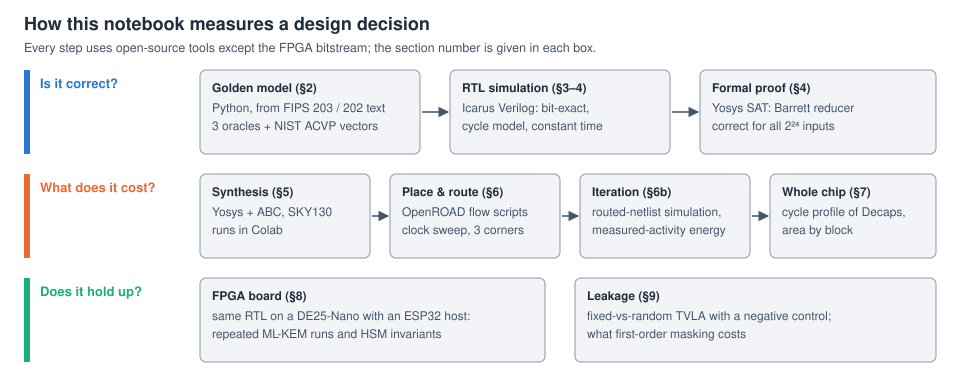

Question,Result,Value,Section
Is it correct?,RTL against the golden model,"0 mismatches over 208,896 NTT coefficients and 404 Keccak permutations, constant latency",§4
,Complete RTL against NIST ACVP keyGen,"25/25 cases byte-exact (ek, dkPKE, z), FPGA and ASIC configurations",§4
,"Barrett reducer, all 2²⁴ inputs",3 variants proven; the negative control fails as it must,§4
What does it cost?,NTT redesign after place-and-route,"area −21%, fmax 49.8 → 82.5 MHz, area × time −46%",§6b
,Energy per forward NTT (routed netlist),2.48 µJ → 1.96 µJ with the 12-bit store,§6b
,Energy per Keccak permutation (routed netlists),"14.6 nJ one round per clock, 80.4 nJ row-serialized",§6
,"Decapsulation, ASIC vs FPGA choices","99,537 vs 81,457 cycles (+22%); the NTT is busy 50%, the Keccak permutation 0.8% of the time",§7
,Full SKY130 core,"11.2 mm² die, 320,615 standard cells, 18 SRAM macros; LVS: circuits match uniquely",§7
Does it hold up?,Same RTL on the DE25-Nano,100/100 two-role ML-KEM runs and 100/100 HSM-invariant runs pass,§8
,Fixed-vs-random TVLA (simulated),"largest t-statistic 49.7 unmasked, 3.6 with first-order masking (leakage threshold 4.5)",§9


In [3]:
import re
display(SVG(filename=str(ROOT/"figures/method_flow.svg")))
R_ = ROOT/"results"
sim_logs = " ".join((R_/"sim"/f"{n}.log").read_text() for n in ["ntt_dualport", "ntt_singleport", "keccak_round", "keccak_serial"])
n_err = sum(int(e) for e in re.findall(r"errors=(\d+)", sim_logs))
n_coef = sum(int(c) for c in re.findall(r"coeffs_checked=(\d+)", sim_logs))
n_kec = sum(int(v) for v in re.findall(r"KECCAK_RESULT serial=\d vectors=(\d+)", sim_logs))
assert n_err == 0 and set(re.findall(r"timing_variations=(\d+)", sim_logs)) == {"0"}
proofs = json.loads((R_/"formal/summary.json").read_text())["results"]
acvp_rtl = json.loads((R_/"acvp_rtl/keygen_asic.json").read_text())
assert all(json.loads((R_/f"acvp_rtl/keygen_{c}.json").read_text())["passed"] == 25 for c in ("fpga", "asic"))
dse =pd.read_csv(R_/"dse_metrics.csv").set_index(["variant", "clk_target_ns"])
o, n = dse.loc[("ntt_sp", 20.0)], dse.loc[("ntt_opt_pipe_w12", 20.0)]
gls = {r: json.loads((R_/"gls_power"/r/"summary.json").read_text()) for r in ["ntt_sp_20ns", "ntt_opt_b1_w12_20ns", "ntt_opt_pipe_w12_20ns"]}
e_uj = {r: g["energy_per_forward_ntt_nj"] / 1e3 for r, g in gls.items()}
kj = {v: json.loads((R_/"gls_power"/f"{v}_20ns"/"summary.json").read_text())["energy_per_permutation_nj"]
      for v in ["keccak_r1", "keccak_s7"]}
prof_ = {c: v["profile"] for c, v in json.loads((R_/"system_sim/decaps_profile.json").read_text())["configs"].items()}
c3 = pd.read_csv(R_/"fpga/c3_repeat.csv"); bank_ = pd.read_csv(R_/"fpga/bank_repeat.csv")
tv = {k: json.loads((R_/d/"tvla_summary.json").read_text()) for k, d in [("plain", "leakage"), ("masked", "leakage_masked")]}
chip = json.loads((R_/"fullchip/summary.json").read_text()); cm = chip["orfs_metrics"]
rows = [
    ("Is it correct?", "RTL against the golden model",
     f"{n_err} mismatches over {n_coef:,} NTT coefficients and {n_kec} Keccak permutations, constant latency", "§4"),
    ("", "Complete RTL against NIST ACVP keyGen",
     f"{acvp_rtl['passed']}/{acvp_rtl['cases']} cases byte-exact (ek, dkPKE, z), FPGA and ASIC configurations", "§4"),
    ("", "Barrett reducer, all 2²⁴ inputs",
     f"{sum(v.startswith('PROVEN') for v in proofs.values())} variants proven; the negative control fails as it must", "§4"),
    ("What does it cost?", "NTT redesign after place-and-route",
     f"area {n.cell_area_um2 / o.cell_area_um2 - 1:+.0%}, fmax {o.fmax_mhz:.1f} → {n.fmax_mhz:.1f} MHz, "
     f"area × time {n.at_product / o.at_product - 1:+.0%}", "§6b"),
    ("", "Energy per forward NTT (routed netlist)",
     f"{e_uj['ntt_sp_20ns']:.2f} µJ → {e_uj['ntt_opt_b1_w12_20ns']:.2f} µJ with the 12-bit store", "§6b"),
    ("", "Energy per Keccak permutation (routed netlists)",
     f"{kj['keccak_r1']:.1f} nJ one round per clock, {kj['keccak_s7']:.1f} nJ row-serialized", "§6"),
    ("", "Decapsulation, ASIC vs FPGA choices",
     f"{prof_['asic']['cycles']:,} vs {prof_['fpga']['cycles']:,} cycles "
     f"(+{prof_['asic']['cycles'] / prof_['fpga']['cycles'] - 1:.0%}); the NTT is busy "
     f"{prof_['fpga']['ntt_busy'] / prof_['fpga']['cycles']:.0%}, the Keccak permutation "
     f"{prof_['fpga']['perm_busy'] / prof_['fpga']['cycles']:.1%} of the time", "§7"),
    ("", "Full SKY130 core",
     f"{cm['finish__design__die__area'] / 1e6:.1f} mm² die, {cm['finish__design__instance__count__stdcell']:,} standard cells, "
     f"{cm['finish__design__instance__count__macros']} SRAM macros; LVS: {chip['signoff']['primary_compare'].lower()}", "§7"),
    ("Does it hold up?", "Same RTL on the DE25-Nano",
     f"{int(c3.result_pass.sum())}/{len(c3)} two-role ML-KEM runs and "
     f"{int((bank_.filter(like='bank_') == 'PASS').all(axis=1).sum())}/{len(bank_)} HSM-invariant runs pass", "§8"),
    ("", "Fixed-vs-random TVLA (simulated)",
     f"largest t-statistic {tv['plain']['max_abs_t']:.1f} unmasked, {tv['masked']['max_abs_t']:.1f} with first-order "
     f"masking (leakage threshold 4.5)", "§9"),
]
nbd.show(pd.DataFrame([(q, r, v.replace('-', '−') if v.startswith('area ') else v, s) for q, r, v, s in rows],
                      columns=["Question", "Result", "Value", "Section"]))

## 1. Context: where these blocks sit in HSKEM

HSKEM (developed under the working name TrustEdge-PQC) is a security co-processor. An ESP32 host issues
commands over SPI; the co-processor keeps every secret on chip, runs ML-KEM-512 key generation,
encapsulation and decapsulation, derives a device root key from a ring-oscillator PUF, and stores wrapped
keys in an A/B vault that survives power loss. I first built and tested the system on a single DE25-Nano
board (about 39,000 ALMs at 50 MHz) and then ported its digital core to SKY130 with
OpenROAD-flow-scripts and OpenRAM.

Most of the arithmetic in ML-KEM falls into two categories:

* **Polynomial arithmetic in $\mathbb{Z}_{3329}[X]/(X^{256}+1)$**, accelerated by the NTT: seven layers of
  128 butterflies per transform, with several transforms in every encapsulation and decapsulation.
* **Keccak-f[1600]** [2, 4], the permutation behind SHAKE and SHA-3, which expands the public matrix, samples
  noise and hashes keys and ciphertexts.

Both blocks were written so that the *same RTL* serves the FPGA and the ASIC, with a single
architectural switch in each:

| Block | FPGA choice | ASIC choice | Why the ASIC differs |
|:---|:---|:---|:---|
| NTT coefficient store | true dual-port RAM (one M20K) | single-port SRAM | The OpenRAM macros available for the chip are single-port. |
| Keccak round | one full round per clock | row-serialized round (seven clocks) | I expected the 1600-bit round logic to be costly in standard cells. |

The rest of the notebook measures what each of these two decisions actually cost.

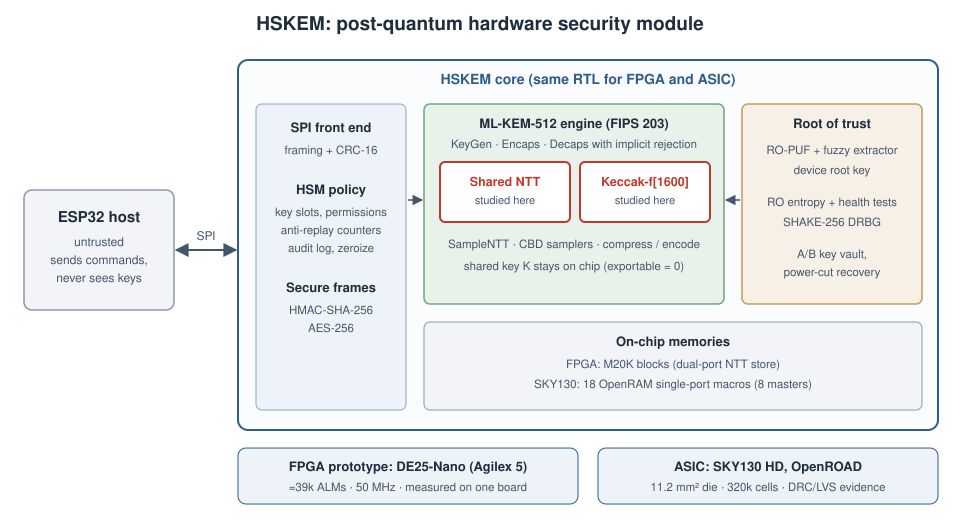

In [4]:
display(SVG(filename=str(ROOT/"figures/hskem_architecture.svg")))

## 2. An independent golden model

The model in `golden/mlkem_ref.py` is written from the text of FIPS 203 and FIPS 202 alone [1, 2]. The twiddle
factors, for example, are recomputed as $\zeta^{\mathrm{BitRev}_7(i)} \bmod q$ with $\zeta = 17$ rather
than copied from the RTL. The model is checked against three oracles that share no code with it:

1. **Mathematics:** $\mathrm{NTT}^{-1}(\mathrm{NTT}(a) \circ \mathrm{NTT}(b))$ must equal the schoolbook negacyclic product $a\cdot b \bmod (X^{256}+1)$.
2. **An independent implementation:** the NTT must agree with [`kyber-py`](https://github.com/GiacomoPope/kyber-py) [12].
3. **The Python standard library:** a SHA3-256 sponge built on my Keccak-f must reproduce `hashlib.sha3_256`.

In [5]:
print("first twiddles:", ref.ZETAS[:8], " 128^-1 mod q =", ref.INV128)
print(ref.self_check(trials=50))

first twiddles: [1, 1729, 2580, 3289, 2642, 630, 1897, 848]  128^-1 mod q = 3303


{'ntt_trials': 50, 'kyber_py_crosscheck': 50, 'sha3_lengths': 6}


The same model also anchors the on-chip self-test. HSKEM's NTT self-test transforms the fixed
polynomial $a_i = 7 + 13i$ and compares a fingerprint of the result — a CRC-16/CCITT-FALSE over the 256
output coefficients followed by their 16-bit sum — with the constant `0xFC3B59FC` hard-coded in the RTL
and firmware. The cell below recomputes that fingerprint from the golden model, using the standard
library's `binascii.crc_hqx` for the CRC, and confirms that the constant corresponds to the FIPS 203 transform.

In [6]:
import binascii
a = [7 + 13 * i for i in range(256)]
out = ref.ntt(a)
digest = (binascii.crc_hqx(b"".join(c.to_bytes(2, "big") for c in out), 0xFFFF) << 16) | (sum(out) & 0xFFFF)
print(f"golden self-test fingerprint: 0x{digest:08X}")
assert digest == 0xFC3B59FC, "on-chip self-test constant does not match the FIPS 203 NTT"

golden self-test fingerprint: 0xFC3B59FC


### From blocks to the whole KEM: NIST ACVP vectors

Building on the validated NTT and Keccak, `golden/mlkem_full.py` implements the complete ML-KEM-512
scheme (FIPS 203, Algorithms 3–18): the encodings, `SampleNTT`, the centred binomial sampler, K-PKE, and
the internal key-generation, encapsulation and decapsulation algorithms, including implicit rejection. It
is checked against the **official NIST ACVP-Server vectors** for ML-KEM-512 [3], stored in `golden/acvp/`
with their provenance in `SOURCE.txt`: 25 key generations, 25 encapsulations and 10 decapsulations, the
latter including modified ciphertexts. Two negative controls confirm that the check is able to fail:
flipping a single input bit must change the result, and a tampered ciphertext must decapsulate to the
implicit-rejection key $J(z\,\|\,c)$ rather than to the genuine shared secret.

In [7]:
import mlkem_full as kem
acvp = kem.acvp_check()
print("NIST ACVP ML-KEM-512:", acvp)
assert all(v.split("/")[0] == v.split("/")[1] for v in acvp.values())

x = bytes.fromhex
tv = json.loads((ROOT/"golden/acvp/mlkem512_keygen.json").read_text())[0]
d = bytearray(x(tv["d"])); d[0] ^= 1
assert kem.keygen_internal(bytes(d), x(tv["z"]))[0] != x(tv["ek"]), "negative control failed"
dv = [t for t in json.loads((ROOT/"golden/acvp/mlkem512_encapdecap.json").read_text())["decapsulation"]
      if t["reason"] == "valid decapsulation"][0]
c = bytearray(x(dv["c"])); c[10] ^= 1
k_rej = kem.decaps_internal(x(dv["dk"]), bytes(c))
assert k_rej != x(dv["k"]) and k_rej == kem.J(x(dv["dk"])[-32:] + bytes(c)), "implicit rejection failed"
print("negative controls: PASS (flipped d -> different ek; tampered c -> J(z||c))")

NIST ACVP ML-KEM-512: {'keyGen': '25/25', 'encapsulation': '25/25', 'decapsulation': '10/10'}
negative controls: PASS (flipped d -> different ek; tampered c -> J(z||c))


## 3. RTL architecture and an analytical cycle model

`rtl/kyber_ntt_engine.sv` processes one butterfly at a time using a single shared multiplier and a
Barrett reducer [5] (`rtl/barrett_reduce.v`, with $M=\lfloor 2^{24}/q \rfloor = 5039$). Each butterfly steps
through a small finite-state machine. The single-port variant needs two additional states, because both
operands and both results must pass through one SRAM port in turn:

| State | Dual-port | Single-port |
|:---|:---|:---|
| FETCH | read $a_j$, $a_{j+len}$ | read $a_j$ |
| CAPTURE | latch both | latch $a_j$, read $a_{j+len}$ |
| CAPTURE_B | — | latch $a_{j+len}$ |
| REDUCE | $\zeta\cdot b$, Barrett reduction | same |
| EXEC | add / subtract mod $q$ | same |
| WRITE | write both | write $a_j$ |
| WRITE_B | — | write $a_{j+len}$ |

With 896 butterflies per transform and one start and one completion cycle, the forward NTT should
therefore take $896 \times 5 + 2$ cycles in the dual-port variant and $896 \times 7 + 2$ in the
single-port variant; the inverse transform adds a scaling pass by $128^{-1}$ of $256 \times 5$ cycles.
`rtl/keccak_f1600_iter.sv` needs $24 + 1$ cycles per permutation when it computes one round per clock,
and $24\times 7 + 1$ when each round is split into a θ-D phase, a θ/ρ/π phase and five χ/ι row phases.
The next section compares these predictions with simulation.

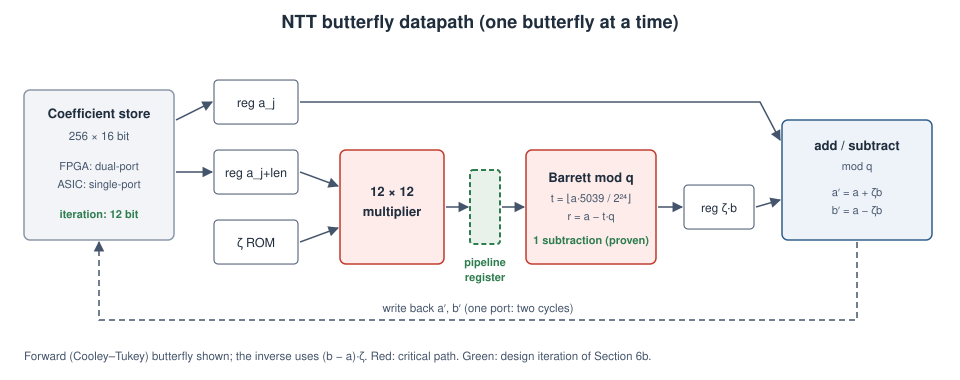

In [8]:
display(SVG(filename=str(ROOT/"figures/ntt_datapath.svg")))

In [9]:
model = {
    "ntt_dp": {"fwd": 896*5 + 2, "inv": 896*5 + 256*5 + 2},
    "ntt_sp": {"fwd": 896*7 + 2, "inv": 896*7 + 256*5 + 2},
    "keccak_r1": {"perm": 24*1 + 1},
    "keccak_s7": {"perm": 24*7 + 1},
}
model

{'ntt_dp': {'fwd': 4482, 'inv': 5762},
 'ntt_sp': {'fwd': 6274, 'inv': 7554},
 'keccak_r1': {'perm': 25},
 'keccak_s7': {'perm': 169}}

### Watching the controller work

`scripts/fsm_trace.sh` simulates one forward transform of each variant with Icarus Verilog, records the
controller's signals in a VCD file and samples its state register at every clock edge. Two checks follow directly
from the trace: the controller visits the 896 butterflies in exactly the order of FIPS 203, Algorithm 9,
and the transform lasts exactly as many cycles as the model above predicts. The first butterflies show
where the two extra cycles of the single-port variant come from: both operands, and later both results,
must take turns on the one memory port.

both controllers visit all 896 butterflies in FIPS 203 order; cycles per forward transform: {'ntt_dp': 4482, 'ntt_sp': 6274}


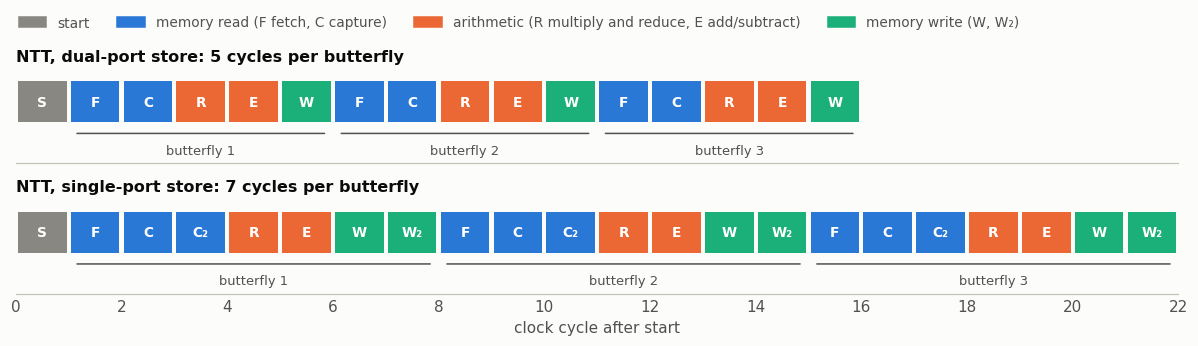

In [10]:
if IN_COLAB or not (ROOT/"results/fsm_trace/ntt_sp.csv").exists():
    sh("bash scripts/fsm_trace.sh 7000")
tr = {v: pd.read_csv(ROOT/"results/fsm_trace"/f"{v}.csv") for v in ["ntt_dp", "ntt_sp"]}
fips_order = [(L, j) for L in (128, 64, 32, 16, 8, 4, 2) for s in range(0, 256, 2 * L) for j in range(s, s + L)]
for v, d in tr.items():
    f = d[d.state == "FETCH"]
    assert list(zip(f.len, f.j)) == fips_order, f"{v}: butterfly order differs from FIPS 203"
    assert len(d) == model[v]["fwd"], f"{v}: trace length differs from the cycle model"
print("both controllers visit all 896 butterflies in FIPS 203 order; cycles per forward transform:",
      {v: len(d) for v, d in tr.items()})

KIND = {"IDLE": ("start", ps.MUTED), "FETCH": ("memory read", ps.SERIES[0]), "CAPTURE": ("memory read", ps.SERIES[0]),
        "CAPTURE_B": ("memory read", ps.SERIES[0]), "REDUCE": ("arithmetic", ps.SERIES[1]),
        "EXEC": ("arithmetic", ps.SERIES[1]), "WRITE": ("memory write", ps.SERIES[2]), "WRITE_B": ("memory write", ps.SERIES[2])}
SHORT = {"IDLE": "S", "FETCH": "F", "CAPTURE": "C", "CAPTURE_B": "C₂", "REDUCE": "R", "EXEC": "E", "WRITE": "W", "WRITE_B": "W₂"}
fig, axes = plt.subplots(2, 1, figsize=(11, 2.9), sharex=True)
for ax, v in zip(axes, ["ntt_dp", "ntt_sp"]):
    per = 5 if v == "ntt_dp" else 7
    d = tr[v].iloc[: 1 + 3 * per]
    for c, s in zip(d.cycle, d.state):
        ax.barh(0, 0.92, left=c + 0.04, height=0.8, color=KIND[s][1])
        ax.text(c + 0.5, 0, SHORT[s], ha="center", va="center", fontsize=9, color="white", fontweight="bold")
    for b in range(3):
        ax.annotate("", (1 + b * per + 0.1, -0.62), (1 + (b + 1) * per - 0.1, -0.62),
                    arrowprops=dict(arrowstyle="-", color=ps.INK_2, lw=1))
        ax.text(1 + b * per + per / 2, -0.95, f"butterfly {b + 1}", ha="center", va="center", fontsize=8.5, color=ps.INK_2)
    ax.set_ylim(-1.2, 0.5); ax.set_yticks([]); ax.grid(False)
    ax.set_title(f"{LABEL[v]}: {per} cycles per butterfly", fontsize=10.5)
    ax.spines["left"].set_visible(False)
axes[-1].set_xlabel("clock cycle after start"); axes[-1].set_xlim(0, 1 + 3 * 7)
axes[-1].set_xticks(range(0, 23, 2))
from matplotlib.patches import Patch
fig.legend([Patch(color=c) for c in (ps.MUTED, ps.SERIES[0], ps.SERIES[1], ps.SERIES[2])],
           ["start", "memory read (F fetch, C capture)", "arithmetic (R multiply and reduce, E add/subtract)",
            "memory write (W, W₂)"], ncols=4, loc="lower left", bbox_to_anchor=(0.01, 0.97), frameon=False, fontsize=9)
fig.tight_layout(); plt.show()

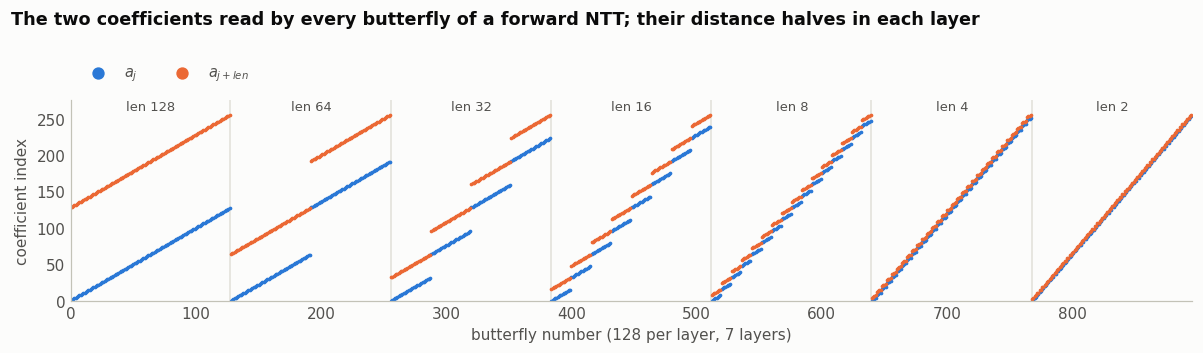

In [11]:
# the memory-access pattern of the whole transform, read from the same trace
f = tr["ntt_sp"][tr["ntt_sp"].state == "FETCH"].reset_index(drop=True)
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.scatter(f.index, f.j, s=2, color=ps.SERIES[0], label="$a_j$", rasterized=True)
ax.scatter(f.index, f.j + f.len, s=2, color=ps.SERIES[1], label="$a_{j+len}$", rasterized=True)
for layer, (L, g) in enumerate(f.groupby("len", sort=False)):
    x0 = g.index.min()
    if layer:
        ax.axvline(x0 - 0.5, color=ps.GRID, lw=1, zorder=0)
    ax.text(x0 + 64, 262, f"len {L}", ha="center", fontsize=8.5, color=ps.INK_2)
ax.set_xlim(0, 896); ax.set_ylim(0, 275); ax.grid(False)
ax.set_xlabel("butterfly number (128 per layer, 7 layers)"); ax.set_ylabel("coefficient index")
ax.legend(loc="lower left", bbox_to_anchor=(0, 1.02), ncols=2, markerscale=5, frameon=False)
fig.suptitle("The two coefficients read by every butterfly of a forward NTT; their distance halves in each layer",
             x=0.01, ha="left", y=0.99, fontsize=11.5, fontweight="bold")
ps.finish(fig); plt.show()

The access pattern explains the architecture. Each layer halves the distance between the two operands of
a butterfly, from 128 coefficients in the first layer to 2 in the last, and every butterfly reads two
coefficients and writes two back. A dual-port memory serves each pair of accesses in one cycle, whereas a
single-port memory needs one cycle per access: exactly the two extra cycles per butterfly seen in the
traces above.

## 4. RTL versus the golden model (Icarus Verilog)

`scripts/run_sim.sh` generates test vectors from the golden model — corner cases followed by random
polynomials and Keccak states — and runs four testbenches. Each bench compares every output coefficient
or state bit exactly, measures the latency, and flags any vector whose latency differs from the others,
which serves as a constant-time check. The Keccak bench additionally verifies that `zeroize` clears the
state. Raising `N` in the cell below runs more random vectors.

In [12]:
N = 60   # random vectors per block (the committed logs used 200)
# writes to results/sim_notebook so the committed 200-vector logs in results/sim stay untouched
out = sh(f"CAC_SIM_OUT=results/sim_notebook CAC_VEC_OUT=vectors_notebook bash scripts/run_sim.sh --ntt {N} --keccak {N} | grep -E 'RESULT|PASS|FAIL'")

NTT_RESULT vectors=64 coeffs_checked=32768 errors=0 cycles_fwd=4482 cycles_inv=5762 timing_variations=0
PASS
NTT_RESULT vectors=64 coeffs_checked=32768 errors=0 cycles_fwd=6274 cycles_inv=7554 timing_variations=0
PASS
KECCAK_RESULT serial=0 vectors=62 errors=0 cycles=25 timing_variations=0
PASS
KECCAK_RESULT serial=1 vectors=62 errors=0 cycles=169 timing_variations=0
PASS
 


In [13]:
import re
SIM_DIR = "results/sim_notebook"   # this run; results/sim holds the committed 200-vector run
def parse_sim():
    rows = {}
    for name, key in [("ntt_dualport","ntt_dp"),("ntt_singleport","ntt_sp"),("keccak_round","keccak_r1"),("keccak_serial","keccak_s7")]:
        log = (ROOT/SIM_DIR/f"{name}.log").read_text()
        d = {k: int(v) for k, v in re.findall(r"(\w+)=(\d+)", log.split("RESULT",1)[1].splitlines()[0])}
        d["pass"] = "PASS" in log
        rows[key] = d
    return pd.DataFrame(rows).T
sim = parse_sim()
sim["model_fwd_or_perm"] = [model[k].get("fwd", model[k].get("perm")) for k in sim.index]
sim["model_inv"] = [model[k].get("inv", np.nan) for k in sim.index]
sim["cycles_measured"] = [int(r.cycles_fwd) if pd.notna(r.get("cycles_fwd")) else int(r.cycles) for _, r in sim.iterrows()]
assert (sim["cycles_measured"] == sim["model_fwd_or_perm"]).all(), "analytical model disagrees with RTL"
assert (sim.loc[["ntt_dp","ntt_sp"], "cycles_inv"] == sim.loc[["ntt_dp","ntt_sp"], "model_inv"]).all()
assert (sim["timing_variations"] == 0).all() and sim["pass"].all()
sim

,vectors,coefficients checked,errors,"cycles, forward NTT","cycles, inverse NTT",latency variations,pass,row-serialized,cycles,model: forward NTT / permutation,model: inverse NTT,cycles measured
"NTT, dual-port store",64,32768,0,4482,5762,0,True,,,4482,5762,4482
"NTT, single-port store",64,32768,0,6274,7554,0,True,,,6274,7554,6274
"Keccak, one round per clock",62,,0,,,0,True,0,25,25,,25
"Keccak, row-serialized",62,,0,,,0,True,1,169,169,,169


### A formal proof for the modular reducer

Simulation covers the vectors it is given; the Barrett reducer admits a stronger argument. Its input is
24 bits wide, so the property $r = a \bmod q$ can be stated for **all** $2^{24}$ inputs and handed to a SAT
solver. `formal/prove_barrett.sh` wraps `rtl/barrett_reduce.v` in a property harness
(`formal/barrett_prop.v`) and asks Yosys' built-in solver for a counterexample.

The proof also answers a design question. The RTL applies up to three conditional subtractions of $q$,
but for this choice of $M = \lfloor 2^{24}/q \rfloor$ the quotient estimate is never more than one below
the true quotient, so one subtraction should suffice. Variants with the third, and with both the second
and third, subtractions removed are proven correct as well, while a negative control with no subtraction
must fail — and does, with a concrete counterexample. An exhaustive NumPy evaluation of the same formula
confirms every result independently.

barrett_proof                              no model found: SUCCESS!
barrett_no_third_correction                no model found: SUCCESS!
barrett_one_correction                     no model found: SUCCESS!
barrett_negative_control_no_correction     model found: FAIL!


exhaustive check: pre-correction remainder in [0, 5713] < 2q; 6,012,719 inputs need exactly one subtraction, none need two


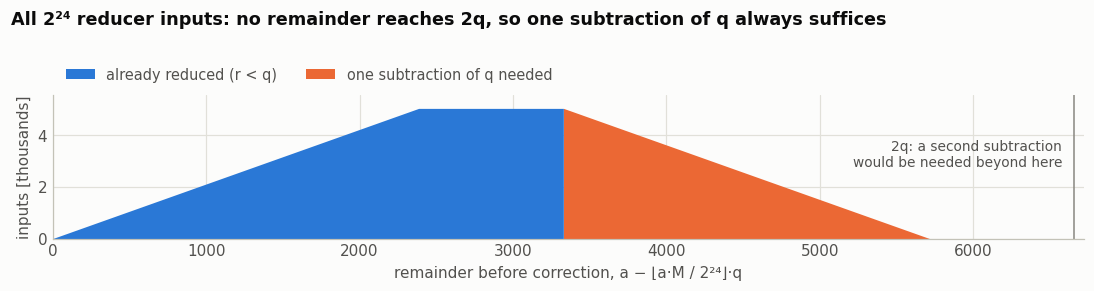

In [14]:
RUN_FORMAL = False   # True re-runs the four SAT proofs (about 15 minutes on one core)
if RUN_FORMAL:
    for impl, tag in [("../rtl/barrett_reduce.v", "barrett_proof"),
                      ("barrett_reduce_no_r3.v", "barrett_no_third_correction"),
                      ("barrett_reduce_one_correction.v", "barrett_one_correction"),
                      ("barrett_reduce_mutant_none.v", "barrett_negative_control_no_correction")]:
        sh(f"bash formal/prove_barrett.sh {impl} {tag}")
for tag in ["barrett_proof", "barrett_no_third_correction", "barrett_one_correction",
            "barrett_negative_control_no_correction"]:
    log = (ROOT/"results/formal"/f"{tag}.log").read_text()
    verdict = re.search(r"SAT proof finished - (.*)", log)[1]
    print(f"{tag:42s} {verdict}")

# independent exhaustive cross-check of the same arithmetic
a = np.arange(1 << 24, dtype=np.int64)
r0 = a - ((a * 5039) >> 24) * 3329
assert r0.min() >= 0 and r0.max() < 2 * 3329
r1 = np.where(r0 >= 3329, r0 - 3329, r0)
assert (r1 == a % 3329).all() and not (r0 == a % 3329).all()
print(f"exhaustive check: pre-correction remainder in [{r0.min()}, {r0.max()}] < 2q; "
      f"{int((r0 >= 3329).sum()):,} inputs need exactly one subtraction, none need two")

# where the 2^24 pre-correction remainders fall
hist = np.bincount(r0, minlength=2 * 3329)
fig, ax = plt.subplots(figsize=(10, 2.6))
ax.fill_between(np.arange(3329), hist[:3329] / 1e3, step="mid", color=ps.SERIES[0], lw=0, label="already reduced (r < q)")
ax.fill_between(np.arange(3329, 2 * 3329), hist[3329:2 * 3329] / 1e3, step="mid", color=ps.SERIES[1], lw=0,
                label="one subtraction of q needed")
ps.reference_line(ax, 2 * 3329, axis="x")
ax.annotate("2q: a second subtraction\nwould be needed beyond here", (2 * 3329, hist.max() / 1e3 * 0.55), xytext=(-8, 0),
            textcoords="offset points", ha="right", fontsize=9, color=ps.INK_2)
ax.set_xlim(0, 2 * 3329 + 60); ax.set_ylim(0, hist.max() / 1e3 * 1.1)
ax.set_xlabel("remainder before correction, a − ⌊a·M / 2²⁴⌋·q"); ax.set_ylabel("inputs [thousands]")
ax.legend(ncols=2, loc="lower left", bbox_to_anchor=(0, 1.0))
fig.suptitle("All 2²⁴ reducer inputs: no remainder reaches 2q, so one subtraction of q always suffices",
             x=0.01, ha="left", y=1.0, fontsize=11.5, fontweight="bold")
ps.finish(fig); plt.show()

### The complete co-processor against the NIST vectors

The checks above establish the golden model against NIST and the blocks against the golden model. The
complete HSKEM RTL can also be confronted with the NIST vectors directly. Its SPI interface accepts a
deterministic key-generation seed $d\,\|\,z$ for test purposes, so `scripts/acvp_rtl_keygen.py` feeds the
co-processor the seeds of all 25 ACVP key-generation test cases, with $k = 2$ as FIPS 203 prescribes for
ML-KEM-512, and compares the key material the RTL leaves in its memories with the NIST answers, byte for
byte: $\mathrm{ek}_\mathrm{PKE} = \mathrm{ByteEncode}_{12}(\hat t)\,\|\,\rho$ (800 bytes),
$\mathrm{dk}_\mathrm{PKE} = \mathrm{ByteEncode}_{12}(\hat s)$ (768 bytes) and $z$. Since
$\mathrm{dk} = \mathrm{dk}_\mathrm{PKE}\,\|\,\mathrm{ek}\,\|\,H(\mathrm{ek})\,\|\,z$, only $H(\mathrm{ek})$, a hash of
the compared ek, is not compared directly. The check runs in both configurations of the RTL: the FPGA configuration, and the ASIC configuration
with the single-port store and the row-serialized Keccak. As a negative control, case 0 is repeated with
$k = 3$, which must not reproduce the NIST key. Encapsulation and decapsulation vectors cannot be applied
the same way: by design, the co-processor accepts no externally supplied encapsulation or decapsulation
key, so those paths are checked by the full-system testbench of Section 7, against values computed by
an independent software model.

In [15]:
RUN_ACVP_RTL = IN_COLAB   # about one minute per configuration
if RUN_ACVP_RTL:
    for cfg in ("fpga", "asic"):
        print(sh(f"python3 scripts/acvp_rtl_keygen.py {cfg}").strip().splitlines()[-1])
for cfg in ("fpga", "asic"):
    r = json.loads((ROOT/f"results/acvp_rtl/keygen_{cfg}.json").read_text())
    diff = sum(c[k] for c in r["details"] for k in c if k.endswith("bytes_diff"))
    print(f"{cfg}: {r['passed']} of {r['cases']} ACVP keyGen cases byte-exact (ekPKE, dkPKE, z; {diff} differing bytes); "
          f"negative control k = 3: {r['negative_control']['ekpke_t_bytes_diff_vs_case_0']} of 768 bytes of t differ")
    assert r["passed"] == r["cases"] == 25 and diff == 0 and r["negative_control"]["ekpke_t_bytes_diff_vs_case_0"] > 0

fpga: 25 of 25 ACVP keyGen cases byte-exact (ekPKE, dkPKE, z; 0 differing bytes); negative control k = 3: 766 of 768 bytes of t differ
asic: 25 of 25 ACVP keyGen cases byte-exact (ekPKE, dkPKE, z; 0 differing bytes); negative control k = 3: 766 of 768 bytes of t differ


## 5. Design-space exploration in Colab: SKY130 logic synthesis

`scripts/synth_sky130.sh` synthesizes each architecture point with Yosys and ABC [11] to the
`sky130_fd_sc_hd` library at its typical corner (25 °C, 1.8 V). It reports the standard-cell area and
ABC's post-mapping combinational delay, an estimate that ignores wires and the clock tree. In this
experiment the coefficient memory is built from flip-flops, so that both NTT variants are compared on
equal terms.

Because the Keccak core has 1600-bit state ports, it is wrapped in `rtl/keccak_lane_wrapper.sv`, which
loads and reads the state one 64-bit lane at a time. The wrapper is identical for both Keccak variants,
so any difference between them is attributable to the core.

In [16]:
SWEEP_CLOCKS = "20"          # "10 20 40" reproduces the full sweep (~15 min)
if IN_COLAB or not list((ROOT/"results/synth").glob("*/summary.json")):
    sh(f"bash scripts/synth_sweep.sh 'ntt_dp ntt_sp keccak_r1 keccak_s7' '{SWEEP_CLOCKS}'")
syn = []
for p in sorted((ROOT/"results/synth").glob("*/summary.json")):
    v, t = re.match(r"(\w+?_\w+?)_(\d+)ns", p.parent.name).groups()
    syn.append({"variant": v, "clk_ns": int(t), **json.loads(p.read_text())})
syn = pd.DataFrame(syn).sort_values(["variant","clk_ns"]).reset_index(drop=True)
syn["cycles"] = syn.variant.map(sim["cycles_measured"])
syn

design,clock target [ns],cell area [µm²],cells,ABC delay estimate [ns],cycles
"Keccak, one round per clock",10,201281.7952,23103,2.4111,25
"Keccak, one round per clock",20,201281.7952,23103,2.4111,25
"Keccak, one round per clock",40,201281.7952,23103,2.4111,25
"Keccak, row-serialized",10,203970.6240,23768,2.5073,169
"Keccak, row-serialized",20,203970.6240,23768,2.5073,169
"Keccak, row-serialized",40,203970.6240,23768,2.5073,169
"NTT, dual-port store",10,238319.8176,27672,15.5569,4482
"NTT, dual-port store",20,238039.5488,27672,18.3328,4482
"NTT, dual-port store",40,238039.5488,27672,18.3328,4482
NTT iteration: 1-subtraction Barrett,10,182372.4096,13164,15.6251,


**Reading the synthesis table.** Both NTT variants store exactly 4096 coefficient bits in flip-flops;
they differ in the second write port and the second read-multiplexer tree of the dual-port store. Both
Keccak variants hold the same 1600-bit state inside the same wrapper. The row-serialized core saves the
χ/ι logic for four of the five rows, but it adds a 320-bit θ-D register and a multi-way next-state
selection on every state bit. Grouping the mapped cells by type shows where the area goes.

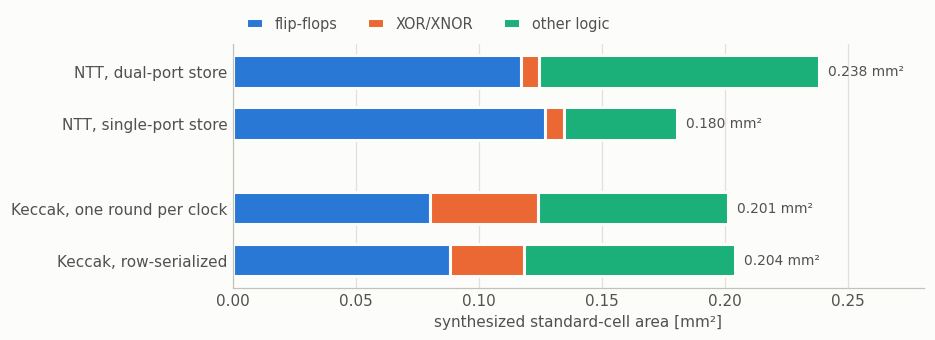

,flip-flops,XOR/XNOR,other logic
"NTT, dual-port store",0.1171,0.0074,0.1136
"NTT, single-port store",0.1269,0.0078,0.0458
"Keccak, one round per clock",0.0803,0.0438,0.0773
"Keccak, row-serialized",0.0884,0.0301,0.0855


In [17]:
def cell_groups(variant, clk=20):
    st = (ROOT/"results/synth"/f"{variant}_{clk}ns"/"stat.txt").read_text()
    g = {"flip-flops": 0.0, "XOR/XNOR": 0.0, "other logic": 0.0}
    for n, area, cell in re.findall(r"^\s*(\d+)\s+([\d.E+-]+)\s+sky130_fd_sc_hd__(\w+)", st, re.M):
        k = "flip-flops" if cell.startswith(("df", "edf")) else "XOR/XNOR" if cell.startswith(("xor", "xnor")) else "other logic"
        g[k] += float(area)
    return g
grp = pd.DataFrame({v: cell_groups(v) for v in ["ntt_dp", "ntt_sp", "keccak_r1", "keccak_s7"]}).T / 1e6

fig, ax = plt.subplots(figsize=(8.6, 3.2))
rows = list(grp.index)[::-1]
ypos = {v: y for y, v in zip([0, 0.8, 2.1, 2.9], rows)}          # a gap separates the two families
left = np.zeros(len(rows))
for slot, part in enumerate(grp.columns):
    vals = grp.loc[rows, part].values
    ax.barh([ypos[v] for v in rows], vals, left=left, height=0.5, label=part, **ps.bar_kw(ps.SERIES[slot]))
    left += vals
for v, total in zip(rows, left):
    ax.annotate(f"{total:.3f} mm²", (total, ypos[v]), xytext=(6, 0), textcoords="offset points",
                va="center", fontsize=9, color=ps.INK_2)
ax.set_yticks([ypos[v] for v in rows], [LABEL[v] for v in rows])
ax.set_xlabel("synthesized standard-cell area [mm²]")
ax.set_xlim(0, left.max() * 1.18); ax.grid(axis="y", visible=False)
ax.legend(ncols=3, loc="lower left", bbox_to_anchor=(0, 1.0), handlelength=1.2)
ps.finish(fig); plt.show()
grp.round(4)

## 6. Physical design: post-route OpenROAD results

Each design point was taken through the complete ORFS flow [8] for the SKY130 HD library [10] — floorplanning,
placement, clock-tree synthesis, and global and detailed routing — using `scripts/run_orfs.sh`. The
figures below are read from the reports that ORFS writes at the end of each run.

**Which fmax?** The design-level worst negative slack includes the I/O budget assumed in the SDC, 20% of
the clock period on each side. For the Keccak wrapper this makes the combinational
`lane_idx → lane_rdata` read path the critical path, which says nothing about the permutation core. The
cores are therefore compared on their worst **register-to-register** slack,
$f_{max} = 1/(T - \mathrm{slack}_{reg\to reg})$, at the typical corner; the design-level value is kept in
the table as `fmax_design_mhz`.

**Power.** OpenSTA's power figures here are vectorless estimates based on default switching activity;
they are omitted from the table and play no part in the conclusions. Power derived from gate-level
switching activity is reported for the Keccak blocks at the end of this section and for the NTT in
Section 6b.

In [18]:
if RUN_PNR:
    sh("bash scripts/sweep.sh 'ntt_dp ntt_sp keccak_r1 keccak_s7' '20' 4")
sh("python3 scripts/collect_metrics.py > /dev/null")
pnr = pd.read_csv(ROOT/"results/dse_metrics.csv")
cols = ["variant","clk_target_ns","flow_rc","die_area_um2","cell_area_um2","flops","wns_ns","reg2reg_slack_ns",
        "fmax_mhz","fmax_design_mhz","drc_errors","antenna_violating_nets","cycles","latency_us_at_fmax","at_product"]
pnr[[c for c in cols if c in pnr]]

design,clock target [ns],flow exit code,die area [µm²],cell area [µm²],flip-flops,design WNS [ns],reg→reg slack [ns],reg→reg fmax [MHz],design fmax [MHz],DRC errors,antenna violations,cycles,latency at fmax [µs],area × time [mm²·µs]
"Keccak, one round per clock",10,0,470850,235078.0,3207,2.0061,5.69,232.0186,125.0960,0,0,25,0.1077,0.0253
"Keccak, one round per clock",20,0,470850,234290.0,3207,7.1845,14.48,181.1594,78.0308,0,0,25,0.1380,0.0323
"Keccak, one round per clock",7,0,470850,237944.0,3207,0.5862,2.82,239.2344,155.9150,0,0,25,0.1045,0.0249
"Keccak, row-serialized",10,0,454316,231333.0,3534,1.3298,4.46,180.5054,115.3380,0,0,169,0.9363,0.2166
"Keccak, row-serialized",20,0,454316,230962.0,3534,6.5019,12.32,130.2083,74.0846,0,0,169,1.2979,0.2998
"Keccak, row-serialized",7,0,454316,235517.0,3534,0.1592,2.09,203.6660,146.1810,0,0,169,0.8298,0.1954
"NTT, dual-port store",15,0,574200,287563.0,4277,-6.0969,-6.10,47.3934,47.4003,0,0,4482,94.5702,27.1949
"NTT, dual-port store",20,0,574200,287711.0,4277,-1.0580,-1.06,47.4834,47.4878,0,0,4482,94.3909,27.1573
"NTT, dual-port store",30,0,574200,281128.0,4277,2.8141,2.81,36.7782,36.7838,0,0,4482,121.8656,34.2598
"NTT, OpenRAM macro store",20,0,293206,38316.7,155,-0.8205,-0.82,48.0307,48.0296,0,0,6274,130.6247,5.0051


**Place-and-route in Colab (optional).** `scripts/make_orfs_bundle.sh` packages the very ORFS build that
produced these results — the same binaries, not a rebuild — together with the libraries it needs into a
single archive that runs on a stock Ubuntu 22.04 machine such as a Colab instance; the build carries no
CPU-specific instructions. Before publication the archive was tested in a pristine Ubuntu 22.04
container on three committed design points — the pipelined NTT (with twelve threads and with the two of a
free Colab instance), the single-port NTT and the one-round-per-clock Keccak core — and every run reproduced
all final metrics of the committed layout. Setting `RUN_PNR_COLAB = True`
downloads the archive from the release of the author's fork, repeats that run and compares every final
metric with the committed one.

In [19]:
bundle = json.loads((ROOT/"results/asic/bundle_reproduction.json").read_text())
for chk in bundle["checks"]:
    print(f"{nbd.label(chk['committed']):<34} {chk['label']}: {chk['identical']} of {chk['metrics_compared']} final metrics identical")
assert all(chk["identical"] == chk["metrics_compared"] for chk in bundle["checks"])

RUN_PNR_COLAB = False     # True: about 130 MB download and 30-45 minutes on a free Colab instance
BUNDLE_URL = ("https://github.com/tandat08052007/sscs-ose-code-a-chip.github.io/releases/download/"
              "hskem-orfs-6101364b/orfs-6101364b-sky130hd.tar.xz")
if RUN_PNR_COLAB:
    bdir = pathlib.Path("/content" if IN_COLAB else pathlib.Path.home())
    if not (bdir/"orfs").exists():
        sh(f"curl -sL {BUNDLE_URL} | tar xJ -C {bdir}")
    work = bdir/"cac_runs"
    target = work/"ntt_opt_pipe_w12_20ns_colab/logs/sky130hd/cac_ntt_opt_pipe_w12_20ns/base/6_report.log"
    sh(f"ORFS_ROOT={bdir}/orfs OPENROAD_EXE={bdir}/orfs/bin/openroad YOSYS_EXE={bdir}/orfs/bin/yosys "
       f"CAC_WORK={work} CAC_TAG_SUFFIX=_colab CAC_TARGET={target} bash scripts/run_orfs.sh ntt_opt_pipe_w12 20")
    print(sh("python3 scripts/compare_runs.py ntt_opt_pipe_w12_20ns ntt_opt_pipe_w12_20ns_colab")[:2000])

NTT iteration: + pipeline, 20 ns   clean ubuntu:22.04 container (udocker), 12 threads: 67 of 67 final metrics identical
NTT iteration: + pipeline, 20 ns   clean ubuntu:22.04 container (udocker), 2 threads, as on a free Colab instance: 67 of 67 final metrics identical
NTT, single-port store, 20 ns      clean ubuntu:22.04 container (udocker), 12 threads: 67 of 67 final metrics identical
Keccak, one round per clock, 20 ns clean ubuntu:22.04 container (udocker), 12 threads: 67 of 67 final metrics identical


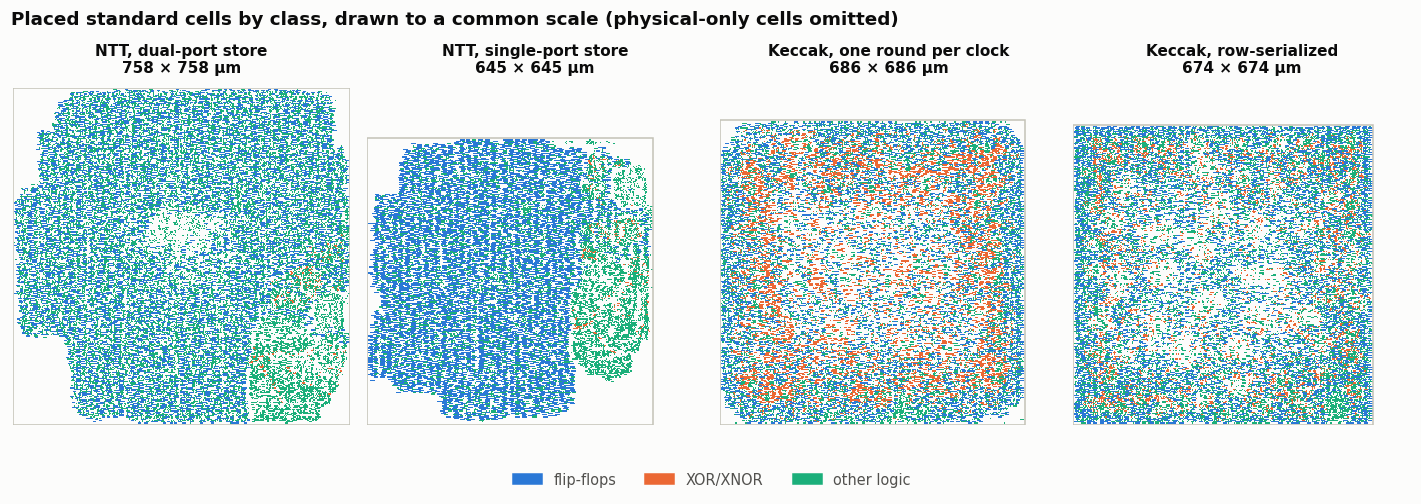

In [20]:
import placement_map as pm
from matplotlib.patches import Patch
runs = ["ntt_dp_20ns", "ntt_sp_20ns", "keccak_r1_20ns", "keccak_s7_20ns"]
extent = max((lambda b: max(b[2] - b[0], b[3] - b[1]))(pm.load(r)[1]) for r in runs)
fig, axes = plt.subplots(1, 4, figsize=(13, 4))
for ax, r in zip(axes, runs):
    pm.draw(ax, r, LABEL[r.rsplit("_", 1)[0]], extent=extent)
fig.legend([Patch(color=c) for _, c in pm.CLASSES], [n for n, _ in pm.CLASSES], ncols=3,
           loc="upper center", bbox_to_anchor=(0.5, 0.0), frameon=False)
fig.suptitle("Placed standard cells by class, drawn to a common scale (physical-only cells omitted)",
             x=0.01, ha="left", y=1.02, fontsize=12, fontweight="bold")
fig.tight_layout(); plt.show()

The placement maps make the architectural differences visible. In the single-port NTT the coefficient
flip-flops form one compact block and the arithmetic sits beside it; in the dual-port NTT the extra write
port's selection logic is spread through the whole store, which is why the block is larger and its wires
longer. In the one-round Keccak core the XOR network of θ and χ forms a distinct ring around the state.
OpenROAD's own rendering of the worst setup path of the single-port NTT confirms where the time goes:
the path (red) starts at a coefficient register, passes the modular subtraction that forms the operand
of the inverse butterfly, then the multiplier and the Barrett reducer, and ends at the reduced-product
register.

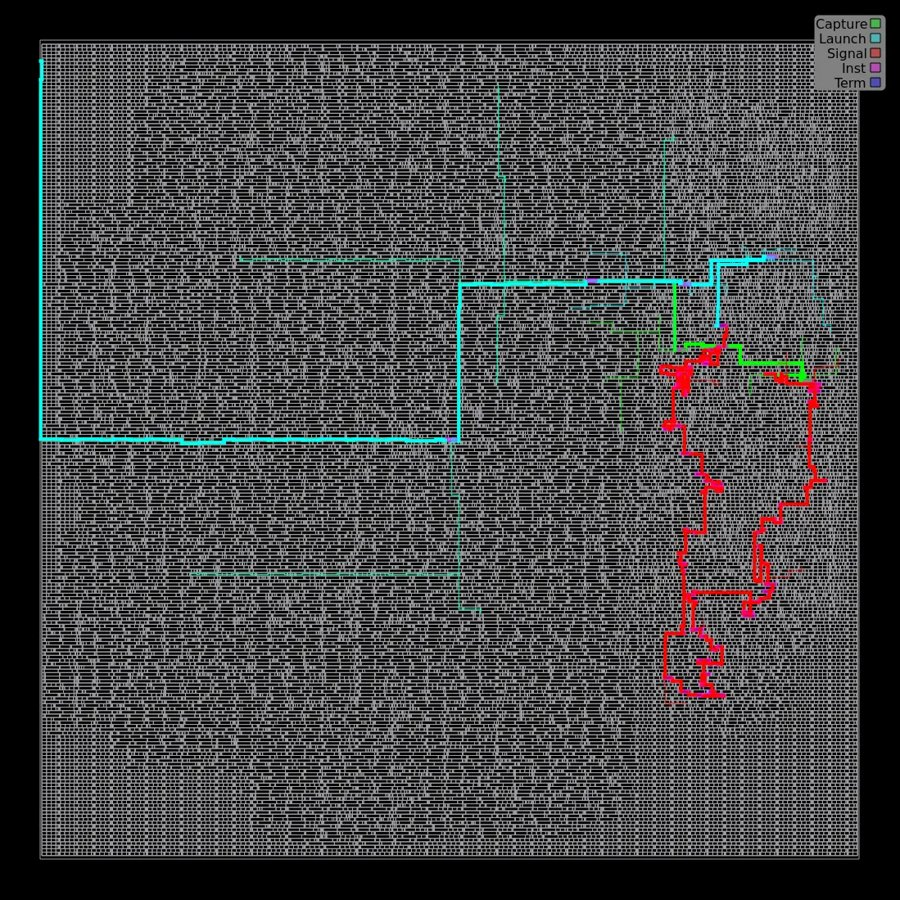

In [21]:
display(Image(str(ROOT/"results/asic/ntt_sp_20ns/worst_path.jpg"), width=520))

The routed layouts themselves, rendered from the final GDS files with KLayout (`scripts/render_gds.py`,
composed by `scripts/make_layout_figures.py`), are shown below at a common scale, together with the NTT
redesign of Section 6b, which is visibly the smallest of the four.

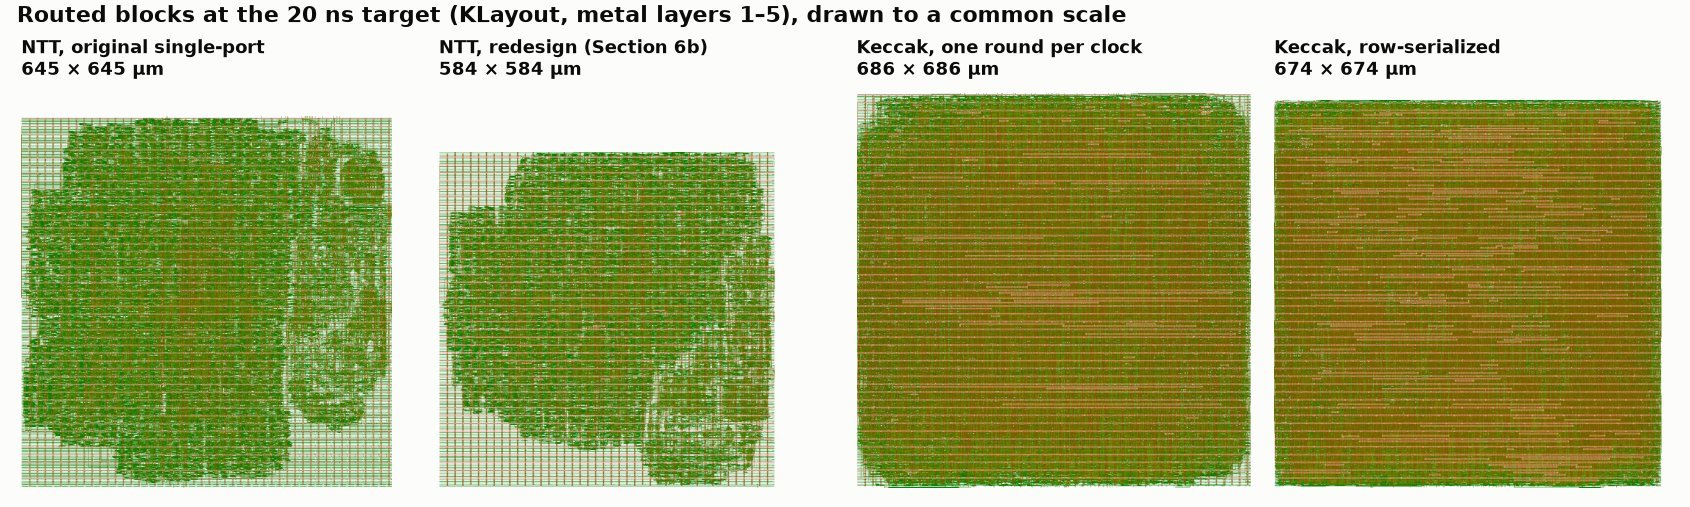

In [22]:
display(Image(str(ROOT/"figures/block_layouts.jpg")))

### Area–latency trade-off

The figure places each design point by its standard-cell area and by the latency of one operation at
its own post-route fmax; points further to the lower left are better. The area–time product (mm²·µs)
condenses both into a single figure of merit that does not depend on how many copies of a block a
designer would instantiate.

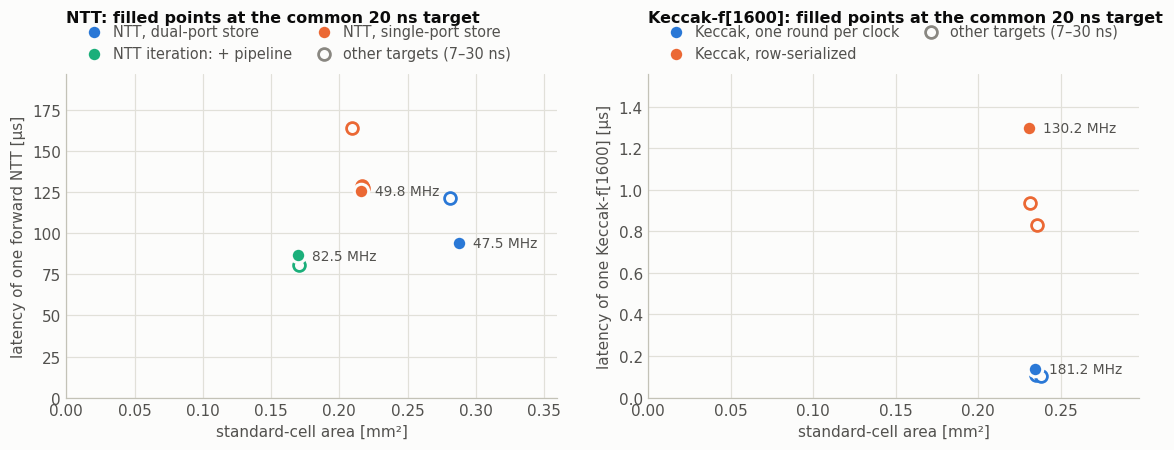

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, fam, op in [(axes[0], "ntt", "one forward NTT"), (axes[1], "keccak", "one Keccak-f[1600]")]:
    # final iteration only; the macro-store point is compared separately (its area is mostly the macro)
    d = pnr[pnr.variant.str.startswith(fam) & ~pnr.variant.isin(["ntt_opt_b1_w12", "ntt_macro", "ntt_opt_pipe_macro"])]
    for v, g in d.groupby("variant", sort=False):
        main = g[g.clk_target_ns == 20]            # the common comparison point carries the label
        rest = g[g.clk_target_ns != 20]
        ax.scatter(main.cell_area_um2 / 1e6, main.latency_us_at_fmax, label=LABEL[v],
                   **{**ps.marker_kw(COLOR[v]), "zorder": 4})   # the labelled 20 ns point stays on top
        if len(rest):
            ax.scatter(rest.cell_area_um2 / 1e6, rest.latency_us_at_fmax, s=60, facecolors=ps.SURFACE,
                       edgecolors=COLOR[v], linewidths=1.8, zorder=3)
        for _, r in main.iterrows():                # one decimal: 49.8 MHz must not read as "50 MHz"
            ax.annotate(f"{r.fmax_mhz:.1f} MHz", (r.cell_area_um2 / 1e6, r.latency_us_at_fmax),
                        xytext=(9, -3), textcoords="offset points", fontsize=9, color=ps.INK_2)
    ax.scatter([], [], s=60, facecolors=ps.SURFACE, edgecolors=ps.MUTED, linewidths=1.8,
               label="other targets (7–30 ns)")   # neutral legend entry for every family colour
    ax.set_xlabel("standard-cell area [mm²]"); ax.set_ylabel(f"latency of {op} [µs]")
    ax.set_title(("NTT" if fam == "ntt" else "Keccak-f[1600]") + ": filled points at the common 20 ns target",
                 pad=34, fontsize=10.5)
    ax.set_ylim(0, d.latency_us_at_fmax.max() * 1.2)
    ax.set_xlim(0, d.cell_area_um2.max() / 1e6 * 1.25)     # zero-based: small area gaps must look small
    ax.legend(ncols=2, loc="lower left", bbox_to_anchor=(0, 1.0), handletextpad=0.3, columnspacing=1.2)
ps.finish(fig); plt.show()

### Response to the clock target

The comparison above uses one common 20 ns target. The supplementary post-route runs at 7 to 30 ns show
how far each block can be pushed. The table lists the reg→reg fmax at every target and the change in
standard-cell area relative to the 20 ns layout.

In [24]:
fx = pnr.pivot(index="variant", columns="clk_target_ns", values="fmax_mhz")
ar = pnr.pivot(index="variant", columns="clk_target_ns", values="cell_area_um2")
darea = 100 * (ar.div(ar[20.0], axis=0) - 1)
show = fx.round(1).astype(object).where(fx.notna(), "")
show.columns = [f"{c:g} ns" for c in show.columns]
display(show.rename(index=LABEL).rename_axis("reg→reg fmax [MHz] at target"))
show = darea.round(1).astype(object).where(darea.notna(), "")
show.columns = [f"{c:g} ns" for c in show.columns]
display(show.rename(index=LABEL).rename_axis("cell-area change vs 20 ns [%]"))
# the statements below rest on these checks
assert fx.loc["keccak_r1", 7.0] > 1.3 * fx.loc["keccak_r1", 20.0] and fx.loc["keccak_s7", 7.0] > 1.5 * fx.loc["keccak_s7", 20.0]
assert darea.loc[["keccak_r1", "keccak_s7"], 7.0].max() < 2.0
assert fx.loc["ntt_dp"].max() < 50 and fx.loc["ntt_sp"].max() < 50
assert darea.loc[["ntt_dp", "ntt_sp"], 30.0].between(-3.5, -1.5).all()   # "saves only 2-3 % of area"
assert fx.loc["ntt_opt_pipe_w12", 12.0] > fx.loc["ntt_sp"].max() * 1.7

reg→reg fmax [MHz] at target,7 ns,10 ns,12 ns,15 ns,20 ns,30 ns
"Keccak, one round per clock",239.2,232.0,,,181.2,
"Keccak, row-serialized",203.7,180.5,,,130.2,
"NTT, dual-port store",,,,47.4,47.5,36.8
"NTT, OpenRAM macro store",,,,,48.0,
NTT iteration: 12-bit store,,,,,52.3,
"NTT iteration: + pipeline, OpenRAM macro store",,,88.7,,82.9,
NTT iteration: + pipeline,,,88.7,,82.5,
"NTT, single-port store",,,48.7,49.0,49.8,38.2


cell-area change vs 20 ns [%],7 ns,10 ns,12 ns,15 ns,20 ns,30 ns
"Keccak, one round per clock",1.6,0.3,,,0.0,
"Keccak, row-serialized",2.0,0.2,,,0.0,
"NTT, dual-port store",,,,-0.1,0.0,-2.3
"NTT, OpenRAM macro store",,,,,0.0,
NTT iteration: 12-bit store,,,,,0.0,
"NTT iteration: + pipeline, OpenRAM macro store",,,0.8,,0.0,
NTT iteration: + pipeline,,,0.6,,0.0,
"NTT, single-port store",,,0.4,0.7,0.0,-3.1


The two families respond differently. Tightening the target from 20 ns to 7 ns raises the
reg→reg frequency of the Keccak cores by about a third (one round per clock) and by more than half
(row-serialized), at a cost of at most 2% in cell area: at 20 ns the flow had no reason to
optimize further once the constraint was met. The original NTT blocks, by contrast, stay below 50 MHz at
every tighter target, because their subtract–multiply–reduce path is a single combinational stage that
gate sizing and buffering barely shorten; relaxing them to 30 ns saves only 2–3% of area. This is the
ceiling that the pipelined design of Section 6b removes.

### The chip's actual store: an OpenRAM macro

The block-level NTT points above build their 4096-bit coefficient store from flip-flops, so that both
memory variants are compared on equal terms. On the chip, however, the store is the single-port OpenRAM
macro `sky130_sram_1rw_16x256_wpr8`. An additional design point takes the same single-port engine
through the same flow with that macro, using the chip's own macro views (`flow/macros/`,
`rtl/sram_macro_16x256.sv`). The controller is unchanged, so its cycle count is the single-port one.
OpenRAM's timing views come from analytical models, and its power views proved non-physical on the chip,
so this point is compared on area and timing only.

In [25]:
def total_area(run):
    j = json.loads(next((ROOT/"results/asic"/run/"logs").rglob("6_report.json")).read_text())
    return j["finish__design__instance__area__stdcell"], j.get("finish__design__instance__area__macros", 0.0)
def slew_violations(run):
    rpt = next((ROOT/"results/asic"/run/"reports").rglob("6_finish.rpt")).read_text()
    sec = rpt.split("report_check_types -max_slew", 1)[1].split("=====", 1)[0]
    slew = sec.split("max slew", 1)[1] if "max slew" in sec else ""       # only the max-slew table
    slew = re.split(r"\nmax (?:capacitance|fanout)", slew)[0]
    return len(re.findall(r"\(VIOLATED\)", slew))
mc = pnr[(pnr.clk_target_ns == 20) & pnr.variant.isin(["ntt_sp", "ntt_macro"])].set_index("variant").loc[["ntt_sp", "ntt_macro"]]
areas = {v: total_area(f"{v}_20ns") for v in mc.index}
store = pd.DataFrame({
    "standard cells [mm²]": [areas[v][0] / 1e6 for v in mc.index],
    "SRAM macro [mm²]": [areas[v][1] / 1e6 for v in mc.index],
    "total [mm²]": [sum(areas[v]) / 1e6 for v in mc.index],
    "die [mm²]": (mc.die_area_um2 / 1e6).values,
    "flip-flops": mc.flops.astype(int).values,
    "fmax [MHz]": mc.fmax_mhz.values,
    "area × time [mm²·µs]": [sum(areas[v]) / 1e6 * mc.loc[v, "latency_us_at_fmax"] for v in mc.index],
    "DRC / antenna": (mc.drc_errors.astype(int).astype(str) + " / " + mc.antenna_violating_nets.astype(int).astype(str)).values,
    "max-slew violations": [slew_violations(f"{v}_20ns") for v in mc.index],
}, index=["flip-flop store", "OpenRAM macro store"])
display(store.round(3))
blk_ntt = pd.read_csv(ROOT/"results/fullchip/blocks.csv").set_index("block").loc["u_shared_ntt", "flops"]
print(f"flip-flops of the macro-store block: {int(mc.loc['ntt_macro', 'flops'])}; of the NTT engine on the chip: {int(blk_ntt)}")
# guards for the statements made in the text below
assert (mc.drc_errors == 0).all() and (mc.antenna_violating_nets == 0).all()
assert 0.6 < store["total [mm²]"].iloc[1] / store["total [mm²]"].iloc[0] < 0.7     # "about a third less"
assert store["standard cells [mm²]"].iloc[1] < 0.2 * store["standard cells [mm²]"].iloc[0]
# the macro is smaller than the flip-flops and multiplexers it replaces
assert store["SRAM macro [mm²]"].iloc[1] < store["standard cells [mm²]"].iloc[0] - store["standard cells [mm²]"].iloc[1]
assert abs(mc.fmax_mhz.iloc[1] / mc.fmax_mhz.iloc[0] - 1) < 0.05
assert abs(int(mc.loc["ntt_macro", "flops"]) - int(blk_ntt)) <= 2
assert store["max-slew violations"].iloc[0] == 0 < store["max-slew violations"].iloc[1]
# the slews quoted in the text: after the post-route step, eight address pins just beyond the 0.04 ns limit
rpt = next((ROOT/"results/asic/ntt_macro_20ns/reports").rglob("6_finish.rpt")).read_text()
sl = sorted(float(x) for x in re.findall(r"u_macro/addr0\[\d\]\s+0\.04\s+([0-9.]+)\s+-[0-9.]+ \(VIOLATED\)", rpt))
assert len(sl) == 8 and all(0.05 <= x <= 0.07 for x in sl), sl
assert "CAC_MACRO_PIN_ECO: upsized 5" in next((ROOT/"results/asic/ntt_macro_20ns/logs").rglob("5_1_grt.log")).read_text()

,standard cells [mm²],SRAM macro [mm²],total [mm²],die [mm²],flip-flops,fmax [MHz],area × time [mm²·µs],DRC / antenna,max-slew violations
flip-flop store,0.216,0.000,0.216,0.416,4267,49.751,27.225,0 / 0,0
OpenRAM macro store,0.038,0.103,0.141,0.293,155,48.031,18.419,0 / 0,8


flip-flops of the macro-store block: 155; of the NTT engine on the chip: 154


With the macro, the block's standard-cell area shrinks to less than a fifth, and even with the macro counted in full
the block needs about a third less area than its flip-flop counterpart; the macro itself is denser than
4096 flip-flops with their write and read multiplexers. Its register count also matches the NTT engine
on the chip within a flip-flop or two, which ties the block-level experiment to the integrated design.
The clock rate barely changes, because the critical path is still the subtract–multiply–reduce stage,
not the macro. One caveat concerns the macro's address pins. The repair that follows global routing splits
the long wires to these pins with minimum-size buffers, whose transitions of up to 0.35 ns far exceeded
the macro's limit, and excluding that cell from the library did not change the choice in this OpenROAD
build. A small engineering-change step, run by the flow as a hook after global routing
(`flow/post_grt_macro_pins.tcl`), therefore upsizes exactly those buffers and re-routes the affected nets.
Eight of the nine address pins still show transitions of 0.05 to 0.07 ns, just beyond the 0.04 ns end of
the macro's characterization table, a limit that the 8- and 12-times buffers now driving them do not
meet; the flip-flop layouts have no such constraint. Together with the single-port constraint of Section 3,
this is the trade-off behind the chip's choice: a markedly smaller store in exchange for two extra
cycles per butterfly and a macro whose electrical views need care.

### Process corners

ORFS closes timing at the typical corner. To see how much margin that leaves, `scripts/sta_corners.sh`
re-times every routed design with OpenSTA and its extracted parasitics (SPEF) at the slow corner
(`ss`, 100 °C, 1.60 V) and the fast corner (`ff`, −40 °C, 1.95 V), using the SKY130A standard-cell
libraries. The typical-corner results reproduce the ORFS figures exactly, which validates the setup.

In [26]:
cor = pd.read_csv(ROOT/"results/sta_corners/summary.csv")
tt = cor[cor.corner == "tt_025C_1v80"].set_index("design")
tt_ref = pnr.assign(design=pnr.variant + "_" + pnr.clk_target_ns.map("{:g}".format) + "ns").set_index("design")
assert (abs(tt.reg2reg_setup_slack_ns - tt_ref.loc[tt.index, "reg2reg_slack_ns"]) < 0.01).all(), "STA setup differs from ORFS"
CORNER_ORDER = ["ss_100C_1v60", "tt_025C_1v80", "ff_n40C_1v95"]
display(cor.pivot(index="design", columns="corner", values="reg2reg_fmax_mhz")[CORNER_ORDER].round(1)
        .rename_axis("reg→reg fmax [MHz]"))
display(cor.pivot(index="design", columns="corner", values="reg2reg_hold_slack_ns")[CORNER_ORDER]
        .rename_axis("reg→reg hold slack [ns]"))
# guards for the statements made in the text below
fx_c = cor.pivot(index="design", columns="corner", values="reg2reg_fmax_mhz")
hold_ff = cor[cor.corner.str.startswith("ff")].set_index("design").hold_wns_ns
assert fx_c["ss_100C_1v60"].div(fx_c["tt_025C_1v80"]).between(0.4, 0.6).all()
assert hold_ff.filter(like="ntt").between(-0.015, 0, inclusive="left").all()
assert (cor[cor.design.str.startswith("keccak")].reg2reg_hold_slack_ns > 0).all()

reg→reg fmax [MHz],"slow corner (ss, 100 °C, 1.60 V)","typical corner (tt, 25 °C, 1.80 V)","fast corner (ff, −40 °C, 1.95 V)"
"Keccak, one round per clock, 20 ns",98.6,181.2,271.7
"Keccak, row-serialized, 20 ns",71.1,130.2,202.4
"NTT, dual-port store, 20 ns",23.4,47.5,76.9
"NTT iteration: 12-bit store, 20 ns",25.1,52.3,85.4
"NTT iteration: + pipeline, 12 ns",42.9,88.6,144.5
"NTT iteration: + pipeline, 20 ns",40.0,82.5,134.0
"NTT, single-port store, 20 ns",24.2,49.8,80.2


reg→reg hold slack [ns],"slow corner (ss, 100 °C, 1.60 V)","typical corner (tt, 25 °C, 1.80 V)","fast corner (ff, −40 °C, 1.95 V)"
"Keccak, one round per clock, 20 ns",0.72,0.22,0.04
"Keccak, row-serialized, 20 ns",0.72,0.21,0.03
"NTT, dual-port store, 20 ns",0.51,0.13,-0.01
"NTT iteration: 12-bit store, 20 ns",0.51,0.13,-0.01
"NTT iteration: + pipeline, 12 ns",0.54,0.14,0.00
"NTT iteration: + pipeline, 20 ns",0.52,0.14,-0.01
"NTT, single-port store, 20 ns",0.52,0.13,-0.01


At the slow corner every block runs at roughly half its typical-corner frequency, so a product clock
would have to be derived from the slow-corner column; the redesigned NTT of Section 6b, which is included in the
table, behaves the same way. At the fast corner every NTT layout shows a small hold violation, between 2
and 14 ps, because ORFS repaired hold only at the typical corner; a hold margin removes it, as shown
next. The Keccak cores meet hold at every corner.

**Removing the fast-corner hold violation.** Where the violating endpoint was traced (four of the five
layouts), it is a single flip-flop, the controller's `done` flag, with 130 to 140 ps of hold slack at the
typical corner. Every NTT layout was therefore re-run with `HOLD_SLACK_MARGIN = 0.17` ns, which makes the typical-corner repair
leave at least that much slack (an earlier attempt with 0.05 ns changed nothing, because every path
already exceeded that margin). Each repaired netlist was analysed again at the three corners and
simulated at gate level against the golden vectors; `scripts/collect_hold_check.py` records the outcome.

In [27]:
hc = json.loads((ROOT/"results/asic/hold_margin_check.json").read_text())["layouts"]
CN = ("ss_100C_1v60", "tt_025C_1v80", "ff_n40C_1v95")
rows = {}
for base, v in hc.items():
    h0, h1 = v["committed"], v["hold margin 0.17 ns"]
    rows[base] = {"ff hold before [ps]": 1e3 * h0["hold_wns_ns_ff_n40C_1v95"],
                  "ff hold after [ps]": 1e3 * h1["hold_wns_ns_ff_n40C_1v95"],
                  "worst hold after, any corner [ps]": 1e3 * min(h1[f"hold_wns_ns_{c}"] for c in CN),
                  "cell change": h1["stdcell_count"] - h0["stdcell_count"],
                  "area change [%]": 100 * (h1["stdcell_area_um2"] / h0["stdcell_area_um2"] - 1),
                  "fmax before [MHz]": h0["fmax_mhz"], "fmax after [MHz]": h1["fmax_mhz"],
                  "GLS after": "pass" if h1["gls_pass"] else "FAIL"}
hct = pd.DataFrame(rows).T.infer_objects()
display(hct.round({c: 0 for c in hct.columns[:3]} | {"area change [%]": 3,
                   "fmax before [MHz]": 2, "fmax after [MHz]": 2}))
# guards for the statements made in the text
assert len(hc) == 5, "every NTT layout of the corner table should have been re-run"
assert (hct["ff hold before [ps]"] < 0).all() and (hct["worst hold after, any corner [ps]"] >= 0).all()
assert (hct["cell change"].abs() <= 6).all() and (hct["area change [%]"].abs() < 0.02).all()
assert (hct["fmax after [MHz]"] / hct["fmax before [MHz]"]).between(0.995, 1.005).all()
assert (hct["GLS after"] == "pass").all()

,ff hold before [ps],ff hold after [ps],"worst hold after, any corner [ps]",cell change,area change [%],fmax before [MHz],fmax after [MHz],GLS after
"NTT, dual-port store, 20 ns",-11,51,51,-5,0.001,47.49,47.49,pass
"NTT, single-port store, 20 ns",-8,59,59,2,0.016,49.74,49.75,pass
"NTT iteration: 12-bit store, 20 ns",-14,50,50,6,0.018,52.28,52.31,pass
"NTT iteration: + pipeline, 20 ns",-8,18,18,3,0.013,82.49,82.39,pass
"NTT iteration: + pipeline, 12 ns",-2,60,60,3,0.018,88.64,88.28,pass


The margin removes the violation at every corner in all five layouts. The cell count changes by at most
six, the standard-cell area by less than two hundredths of a percent and the clock rate by less than half
a percent; every repaired netlist still passes gate-level simulation. The
comparisons in the rest of this notebook use the original layouts, routed with the default ORFS settings;
since the repair changes no figure beyond the second decimal, none of those comparisons is affected.

### Energy per Keccak permutation

`scripts/run_gls_power_keccak.sh` repeats for both routed Keccak blocks what Section 6b does for the NTT:
it simulates the routed netlist with the SKY130 cell models through the lane wrapper
(`tb/tb_keccak_lanes.sv`), checks every output lane against the golden model, records the switching
activity of exactly one permutation of a random state, and lets OpenSTA combine it with the extracted
parasitics. Energy per permutation is power × cycles × clock period at the common 20 ns clock.

In [28]:
def energy_spread(run):
    # energy of the committed input and of four further random inputs (seeds 1-4, results/gls_power/<run>_seed*)
    e = [next(v for k, v in json.loads((ROOT/"results/gls_power"/d/"summary.json").read_text()).items()
              if k.startswith("energy_per")) for d in [run] + [f"{run}_seed{i}" for i in (1, 2, 3, 4)]]
    return 100 * (max(e) - min(e)) / np.mean(e)
ke = {v: json.loads((ROOT/"results/gls_power"/f"{v}_20ns"/"summary.json").read_text()) for v in ["keccak_r1", "keccak_s7"]}
ke = pd.DataFrame(ke).T
assert ke.gls_pass.all(), "a routed Keccak netlist failed gate-level simulation"
assert (ke.cycles_perm.astype(int) == [model["keccak_r1"]["perm"], model["keccak_s7"]["perm"]]).all()
kgrp = {}
for v in ke.index:
    kgrp[v] = {g: float(s) / 100 for g, s in re.findall(r"^(Sequential|Combinational|Clock)\s.*?([\d.]+)%\s*$",
               (ROOT/"results/gls_power"/f"{v}_20ns"/"power.log").read_text(), re.M)}
tab = pd.DataFrame({
    "cycles / permutation": ke.cycles_perm.astype(int),
    "power [mW]": ke.total_power_w.astype(float) * 1e3,
    "energy / permutation [nJ]": ke.energy_per_permutation_nj.astype(float),
    "clock tree + flip-flops [% of power]": [100 * (kgrp[v]["Clock"] + kgrp[v]["Sequential"]) for v in ke.index],
    "energy spread, 5 inputs [%]": [energy_spread(f"{v}_20ns") for v in ke.index],
}).rename(index=LABEL)
assert (tab["energy spread, 5 inputs [%]"] < 0.5).all(), "the energy now depends noticeably on the input"
e_ratio = ke.loc["keccak_s7", "energy_per_permutation_nj"] / ke.loc["keccak_r1", "energy_per_permutation_nj"]
p_ratio = ke.loc["keccak_s7", "total_power_w"] / ke.loc["keccak_r1", "total_power_w"]
print(f"row-serialized / one round per clock: power x{p_ratio:.2f}, energy per permutation x{e_ratio:.1f}")
assert 5 < e_ratio < 6 and 0.75 < p_ratio < 0.9     # stated in the text below
assert kgrp["keccak_s7"]["Clock"] + kgrp["keccak_s7"]["Sequential"] > 0.65
tab.round(2)

row-serialized / one round per clock: power x0.82, energy per permutation x5.5


,cycles / permutation,power [mW],energy / permutation [nJ],clock tree + flip-flops [% of power],"energy spread, 5 inputs [%]"
"Keccak, one round per clock",25,29.1,14.55,58.7,0.34
"Keccak, row-serialized",169,23.8,80.44,69.4,0.42


Both routed Keccak blocks compute the permutation bit-exactly, and four further random states change
the energy per permutation by less than half a percent. Row-serialization lowers the power drawn
per cycle by less than a fifth, but it needs almost seven times as many cycles, so each permutation costs
about five and a half times more energy. The reason is visible in the power groups: the clock tree and
the 1600-bit state registers, which are clocked in every cycle whether a round is being computed or not,
account for two thirds of the row-serialized block's power. Serializing the round logic therefore saves
almost no area and costs energy in this design.

## 6b. Closing the loop: a measured design iteration of the NTT

The measurements so far point to three concrete improvements for the ASIC NTT: the Barrett reducer
carries two provably redundant subtraction stages (Section 4), the critical path runs through the
multiplier and the reducer (Section 6), and the coefficient store keeps four bits that are always zero
(Section 8). `rtl/kyber_ntt_engine_opt.sv` implements all three behind parameters, so that each can be
evaluated on its own:

| Parameter | Effect |
|:---|:---|
| `BARRETT_1C` | single-subtraction Barrett reducer (`rtl/barrett_reduce_1c.v`), proven equivalent |
| `PIPE_MUL` | a register between the multiplier and the reducer; one extra cycle per butterfly |
| `COEFF_W = 12` | a 12-bit coefficient store, lossless because $q < 2^{12}$ |

With all three disabled the variant is cycle-identical to the original single-port engine, which serves
as the reference. Every variant is checked against the golden model exactly as in Section 4.

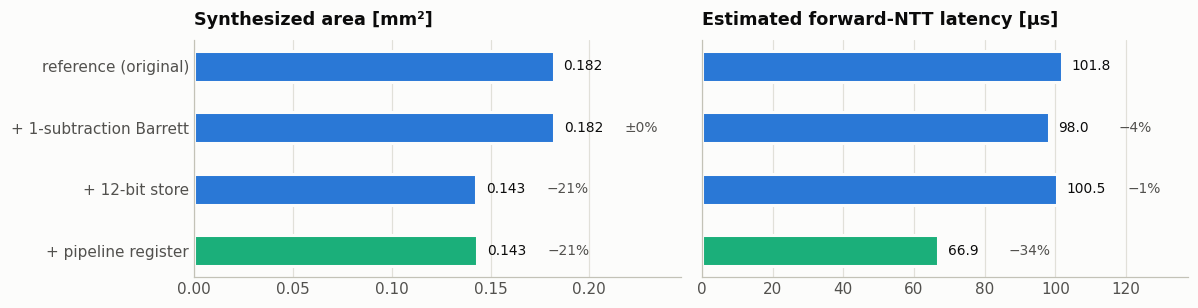

,simulation errors,latency variations,"cycles, forward NTT","cycles, inverse NTT",cell area [µm²],ABC delay estimate [ns],estimated forward latency [µs],area vs reference,delay vs reference,latency vs reference
NTT iteration: reference (single-port),0,0,6274,7554,181904.4608,16.2298,101.83,+0.0%,+0.0%,+0.0%
NTT iteration: 1-subtraction Barrett,0,0,6274,7554,182372.4096,15.6251,98.03,+0.3%,-3.7%,-3.7%
NTT iteration: 12-bit store,0,0,6274,7554,142878.2816,16.0129,100.47,-21.5%,-1.3%,-1.3%
NTT iteration: + pipeline,0,0,7170,8706,143372.5056,9.3280,66.88,-21.2%,-42.5%,-34.3%


In [29]:
if IN_COLAB:
    sh("bash scripts/run_sim_opt.sh")
    sh("bash scripts/synth_sweep.sh 'ntt_opt_ref ntt_opt_b1 ntt_opt_b1_w12 ntt_opt_pipe_w12' '10'")
opt = json.loads((ROOT/"results/synth/ntt_opt_summary.json").read_text())["variants"]
opt = pd.DataFrame(opt).T[["sim_errors", "timing_variations", "cycles_fwd", "cycles_inv",
                           "cell_area_um2", "abc_comb_delay_ns", "est_fwd_latency_us"]]
assert (opt.sim_errors == 0).all() and (opt.timing_variations == 0).all()
assert opt.loc["ntt_opt_ref", "cycles_fwd"] == sim.loc["ntt_sp", "cycles_measured"]
ref = opt.loc["ntt_opt_ref"]
opt["area_vs_ref"] = (opt.cell_area_um2 / ref.cell_area_um2 - 1).map("{:+.1%}".format)
opt["delay_vs_ref"] = (opt.abc_comb_delay_ns / ref.abc_comb_delay_ns - 1).map("{:+.1%}".format)
opt["latency_vs_ref"] = (opt.est_fwd_latency_us / ref.est_fwd_latency_us - 1).map("{:+.1%}".format)

names = {"ntt_opt_ref": "reference (original)", "ntt_opt_b1": "+ 1-subtraction Barrett",
         "ntt_opt_b1_w12": "+ 12-bit store", "ntt_opt_pipe_w12": "+ pipeline register"}
order = list(names)[::-1]
fig, axes = plt.subplots(1, 2, figsize=(11, 2.9), sharey=True)
for ax, col, unit, title in [(axes[0], "cell_area_um2", 1e6, "Synthesized area [mm²]"),
                             (axes[1], "est_fwd_latency_us", 1, "Estimated forward-NTT latency [µs]")]:
    vals = opt.loc[order, col].astype(float) / unit
    colours = [ps.SERIES[2] if v == "ntt_opt_pipe_w12" else ps.SERIES[0] for v in order]
    ax.barh(range(len(order)), vals, height=0.5, color=colours, edgecolor=ps.SURFACE, linewidth=2)
    for y, (v, x) in enumerate(zip(order, vals)):
        rel = x / (float(opt.loc["ntt_opt_ref", col]) / unit) - 1
        ax.annotate(f"{x:.3f}" if unit != 1 else f"{x:.1f}", (x, y), xytext=(6, 0), textcoords="offset points",
                    va="center", fontsize=9, color=ps.INK)
        if v != "ntt_opt_ref":
            txt = "±0%" if abs(rel) < 0.005 else f"{rel:+.0%}".replace("-", "−")
            ax.annotate(txt, (x, y), xytext=(46, 0), textcoords="offset points",
                        va="center", fontsize=9, color=ps.INK_2)
    ax.set_title(title); ax.grid(axis="y", visible=False); ax.set_xlim(0, vals.max() * 1.35)
axes[0].set_yticks(range(len(order)), [names[v] for v in order])
ps.finish(fig); plt.show()
opt

At the synthesis level the picture is clear and partly unexpected. Removing the redundant subtractions
barely changes the delay: the long path is the pair of multiplications inside the reducer, not the final
corrections. Narrowing the store to 12 bits removes about a fifth of the block's area, since storage
dominates it. The pipeline register nearly halves the combinational delay for one extra cycle per
butterfly, which shortens the estimated transform latency by about a third.

The two meaningful iterations were then taken through the same complete place-and-route flow as the
original blocks, at the same 20 ns target, so that the comparison below is between routed layouts.

In [30]:
it = pnr[(pnr.clk_target_ns == 20) & pnr.variant.isin(["ntt_sp", "ntt_opt_b1_w12", "ntt_opt_pipe_w12"])]
it = it.set_index("variant").loc[["ntt_sp", "ntt_opt_b1_w12", "ntt_opt_pipe_w12"]]
base_it = it.loc["ntt_sp"]
tab = pd.DataFrame({
    "cell area [mm²]": it.cell_area_um2 / 1e6,
    "flip-flops": it.flops.astype(int),
    "fmax [MHz]": it.fmax_mhz,
    "cycles / forward NTT": it.cycles.astype(int),
    "latency [µs]": it.latency_us_at_fmax,
    "area × time [mm²·µs]": it.at_product,
    "DRC / antenna": it.drc_errors.astype(int).astype(str) + " / " + it.antenna_violating_nets.astype(int).astype(str),
}).rename(index={"ntt_sp": "original (single-port)", "ntt_opt_b1_w12": "+ 1-subtraction Barrett, 12-bit store",
                 "ntt_opt_pipe_w12": "+ pipeline register"})
assert (it.drc_errors == 0).all() and (it.antenna_violating_nets == 0).all()
assert it.loc["ntt_opt_pipe_w12", "latency_us_at_fmax"] < 0.75 * base_it.latency_us_at_fmax
assert it.loc["ntt_opt_b1_w12", "cell_area_um2"] < 0.8 * base_it.cell_area_um2
assert it.loc["ntt_opt_b1_w12", "fmax_mhz"] >= 50 > base_it.fmax_mhz
assert base_it.flops - it.loc["ntt_opt_b1_w12", "flops"] == 1024 + 4    # stated in the text below
tab.round(3)

design,cell area [mm²],flip-flops,fmax [MHz],cycles / forward NTT,latency [µs],area × time [mm²·µs],DRC / antenna
original (single-port),0.216,4267,49.751,6274,126.107,27.225,0 / 0
"+ 1-subtraction Barrett, 12-bit store",0.168,3239,52.274,6274,120.022,20.125,0 / 0
+ pipeline register,0.170,3265,82.508,7170,86.900,14.754,0 / 0


Place-and-route confirms the synthesis estimates. The 12-bit store removes 1,028 flip-flops — the 1,024
unused storage bits plus the four upper bits of the read register — and a fifth of the cell area, and the
lighter layout now closes the original 50 MHz target that neither original NTT met. The pipeline register
lifts the post-route frequency by about two thirds, which more than repays its extra cycle per butterfly:
a forward transform finishes about 30% sooner, and the area–time product falls by almost half. Both
iterations are free of DRC and antenna violations.

A tighter 12 ns target separates the two architectures further: the pipelined NTT closes timing there,
while the original saturates just below 50 MHz however hard the flow is pushed, because only the extra
register shortens its critical path appreciably.

In [31]:
t12 = pnr[(pnr.clk_target_ns == 12) & pnr.variant.isin(["ntt_sp", "ntt_opt_pipe_w12"])].set_index("variant")
if len(t12) == 2:
    assert t12.loc["ntt_opt_pipe_w12", "reg2reg_slack_ns"] >= 0 > t12.loc["ntt_sp", "reg2reg_slack_ns"]
    display(t12[["cell_area_um2", "reg2reg_slack_ns", "fmax_mhz", "latency_us_at_fmax", "drc_errors",
                 "antenna_violating_nets"]].rename(index=LABEL).round(2))

design,cell area [µm²],reg→reg slack [ns],reg→reg fmax [MHz],latency at fmax [µs],DRC errors,antenna violations
NTT iteration: + pipeline,170828,0.72,88.65,80.88,0,0
"NTT, single-port store",216822,-8.53,48.71,128.81,0,0


### Gate-level verification and measured-activity energy

Two further checks close the physical-design loop. `scripts/run_gls_power.sh` simulates each routed
netlist with the SKY130 cell models against the golden vectors, so the layout itself — not only the RTL —
is shown to compute the transform bit-exactly. The same simulation records the switching activity of one
forward NTT of a random polynomial; OpenSTA then combines that activity with the extracted parasitics to
report power, replacing the vectorless estimates. Energy per transform is power × cycles × clock period
at the common 20 ns clock.

The functional half of this check also runs in Colab: `scripts/run_gls.sh` simulates a committed routed
netlist from `results/asic/` with the SKY130 cell models shipped in `third_party/`, so no PDK download is
needed. The power half needs OpenSTA and the extracted parasitics and is reported from the committed runs.

In [32]:
RUN_GLS = IN_COLAB   # re-simulate the routed netlist of the pipelined NTT (about 5-8 minutes)
if RUN_GLS:
    out = sh("bash scripts/run_gls.sh ntt_opt_pipe_w12_20ns")
    assert "errors=0" in out and "PASS" in out, "the routed netlist failed gate-level simulation"
gp = {}
for r in ["ntt_sp_20ns", "ntt_opt_b1_w12_20ns", "ntt_opt_pipe_w12_20ns"]:
    f = ROOT/"results/gls_power"/r/"summary.json"
    if f.exists():
        gp[r.rsplit("_", 1)[0]] = json.loads(f.read_text())
gp = pd.DataFrame(gp).T
assert gp.gls_pass.all(), "a routed netlist failed gate-level simulation"
gp["power [mW]"] = gp.total_power_w.astype(float) * 1e3
gp["energy / forward NTT [µJ]"] = gp.energy_per_forward_ntt_nj.astype(float) / 1e3
gp.index = [LABEL.get(v, v) for v in gp.index]
if len(gp) == 3:
    e = gp["energy / forward NTT [µJ]"].astype(float).values
    assert e[1] < e[2] < e[0], "energy ordering stated in the text no longer holds"
    assert 0.75 < e[1] / e[0] < 0.85, "the 12-bit store no longer saves about a fifth of the energy"
# power groups of the original block, as reported by OpenSTA
grp_pw = {g: float(s) / 100 for g, s in re.findall(r"^(Sequential|Clock)\s.*?([\d.]+)%\s*$",
          (ROOT/"results/gls_power/ntt_sp_20ns/power.log").read_text(), re.M)}
print("original single-port NTT, share of power:", {g: f"{s:.0%}" for g, s in grp_pw.items()})
assert 0.45 < grp_pw["Sequential"] < 0.55 and 0.35 < grp_pw["Clock"] < 0.45
gp["energy spread, 5 inputs [%]"] = [energy_spread(r) for r in ["ntt_sp_20ns", "ntt_opt_b1_w12_20ns", "ntt_opt_pipe_w12_20ns"]]
assert (gp["energy spread, 5 inputs [%]"] < 0.2).all(), "the energy now depends noticeably on the input"
gp[["gls_pass", "cycles_fwd", "power [mW]", "energy / forward NTT [µJ]", "energy spread, 5 inputs [%]"]].round(3)

original single-port NTT, share of power: {'Sequential': '50%', 'Clock': '40%'}


,gate-level simulation passed,"cycles, forward NTT",power [mW],energy / forward NTT [µJ],"energy spread, 5 inputs [%]"
"NTT, single-port store",True,6274,19.758,2.479,0.106
NTT iteration: 12-bit store,True,6274,15.626,1.961,0.122
NTT iteration: + pipeline,True,7170,15.668,2.247,0.103


All three routed netlists compute the transform bit-exactly, and repeating the energy measurement for
four further random polynomials changes it by less than 0.2 %. At the common clock, half of the original
block's power is spent in its flip-flops and a further two fifths in the clock tree that feeds them — the
price of building a 4096-bit memory from standard cells. Removing a quarter of that storage lowers the
energy of a transform by about a fifth. The pipeline register costs energy rather than saving it: its
extra cycle per butterfly raises the energy per transform again, so the fastest variant remains cheaper
than the original but is not the most frugal one. Which of the two to choose is a speed-versus-energy
decision that these numbers now make explicit.

### The iteration with the chip's own store

The iteration above was measured with the flip-flop store used throughout the block-level comparison.
To confirm that its benefit carries over to the chip, the pipelined iteration was also taken through the
flow with the chip's OpenRAM macro as its store (`rtl/sram_macro_16x256_opt.sv`), exactly like the
macro-store point of Section 6, including the post-route step on the macro's address pins.

In [33]:
om = pnr[pnr.variant.isin(["ntt_macro", "ntt_opt_pipe_macro"])].copy()
om["design"] = om.variant.map(LABEL) + ", " + om.clk_target_ns.map("{:g} ns".format)
om["total area [mm²]"] = [sum(total_area(f"{v}_{c:g}ns")) / 1e6 for v, c in zip(om.variant, om.clk_target_ns)]
om["area × time, total [mm²·µs]"] = om["total area [mm²]"] * om.latency_us_at_fmax
omt = om.set_index("design")[["cell_area_um2", "total area [mm²]", "flops", "fmax_mhz", "cycles",
                               "latency_us_at_fmax", "area × time, total [mm²·µs]", "drc_errors", "antenna_violating_nets"]]
display(omt.round(3))
a0 = om[(om.variant == "ntt_macro") & (om.clk_target_ns == 20)].iloc[0]
a1 = om[(om.variant == "ntt_opt_pipe_macro") & (om.clk_target_ns == 20)].iloc[0]
a2 = om[(om.variant == "ntt_opt_pipe_macro") & (om.clk_target_ns == 12)].iloc[0]
print(f"pipelined iteration vs original, both with the macro at 20 ns: fmax {a0.fmax_mhz:.1f} -> {a1.fmax_mhz:.1f} MHz, "
      f"latency {a0.latency_us_at_fmax:.0f} -> {a1.latency_us_at_fmax:.0f} us, standard cells {a1.cell_area_um2 / a0.cell_area_um2 - 1:+.0%}")
# guards for the statements made in the text below
assert (om.drc_errors == 0).all() and (om.antenna_violating_nets == 0).all()
assert 1.6 < a1.fmax_mhz / a0.fmax_mhz < 1.8 and 0.8 < a1.cell_area_um2 / a0.cell_area_um2 < 0.9
assert a1.latency_us_at_fmax < 0.75 * a0.latency_us_at_fmax and a2.fmax_mhz > 1e3 / 12
sl = {r: slew_violations(r) for r in ("ntt_opt_pipe_macro_20ns", "ntt_opt_pipe_macro_12ns")}
rpt = next((ROOT/"results/asic/ntt_opt_pipe_macro_20ns/reports").rglob("6_finish.rpt")).read_text()
pin = [float(x) for x in re.findall(r"u_macro/addr0\[\d\]\s+0\.04\s+([0-9.]+)\s", rpt)]
assert max(pin) <= 0.07 and re.search(r"\s1\.50\s+1\.52\s+-0\.02 \(VIOLATED\)", rpt)

design,cell area [µm²],total area [mm²],flip-flops,reg→reg fmax [MHz],cycles,latency at fmax [µs],"area × time, total [mm²·µs]",DRC errors,antenna violations
"NTT, OpenRAM macro store, 20 ns",38316.7,0.141,155,48.031,6274,130.625,18.419,0,0
"NTT iteration: + pipeline, OpenRAM macro store, 12 ns",32856.5,0.136,181,88.652,7170,80.878,10.963,0,0
"NTT iteration: + pipeline, OpenRAM macro store, 20 ns",32582.5,0.135,181,82.850,7170,86.542,11.707,0,0


pipelined iteration vs original, both with the macro at 20 ns: fmax 48.0 -> 82.9 MHz, latency 131 -> 87 us, standard cells -15%


With the macro store the pipelined iteration behaves as it does with flip-flops: it clocks about
seven tenths faster than the original engine with the same macro, finishes a forward transform in about
two thirds of the time and needs about a sixth less standard-cell area, and at a 12 ns target it closes
timing near 89 MHz. Both layouts are free of DRC and antenna violations. Their macro address pins show
the same marginal transitions of at most 0.07 ns as the original macro point, and in the 20 ns layout
one internal net exceeds the standard cells' 1.5 ns transition limit by 0.02 ns.

## 7. The full HSKEM core on SKY130

On the chip, the blocks above are integrated into a single digital core together with the SPI front end, the HSM
policy logic, SHA-256/HMAC, AES-256, the PUF root and vault services, and 18 OpenRAM [9] SRAM macros
drawn from eight distinct masters. This ASIC build uses the **row-serialized Keccak** and the **single-port
NTT store** examined above.

The layout was verified hierarchically. Each SRAM master has its own transistor-level LVS in Netgen, and
the top level is compared with those masters abstracted to their pin frames. A repeat run and a negative
control, in which one deliberately altered endpoint must be detected, guard the comparison flow itself.

die area [mm²]                                                               11.2314
std cells                                                                     320615
std-cell area [mm²]                                                          2.03292
SRAM macros                                                                       18
SRAM area [mm²]                                                              2.16121
flip-flops                                                                     28460
clock target [ns]                                                               40.0
setup WNS [ns]                                                               4.89328
hold WNS [ns]                                                               0.119253
post-route fmax [MHz]                                                        37.8185
LVS (primary / repeat)             Circuits match uniquely / Circuits match uniquely
LVS negative control detected                                    

claim boundary: pre-silicon top-level integration LVS with 8 SRAM abstractions and independent transistor-level LVS for each SRAM
power: NOT REPORTED: ORFS power total in this run is non-physical (SRAM liberty power model); excluded on purpose


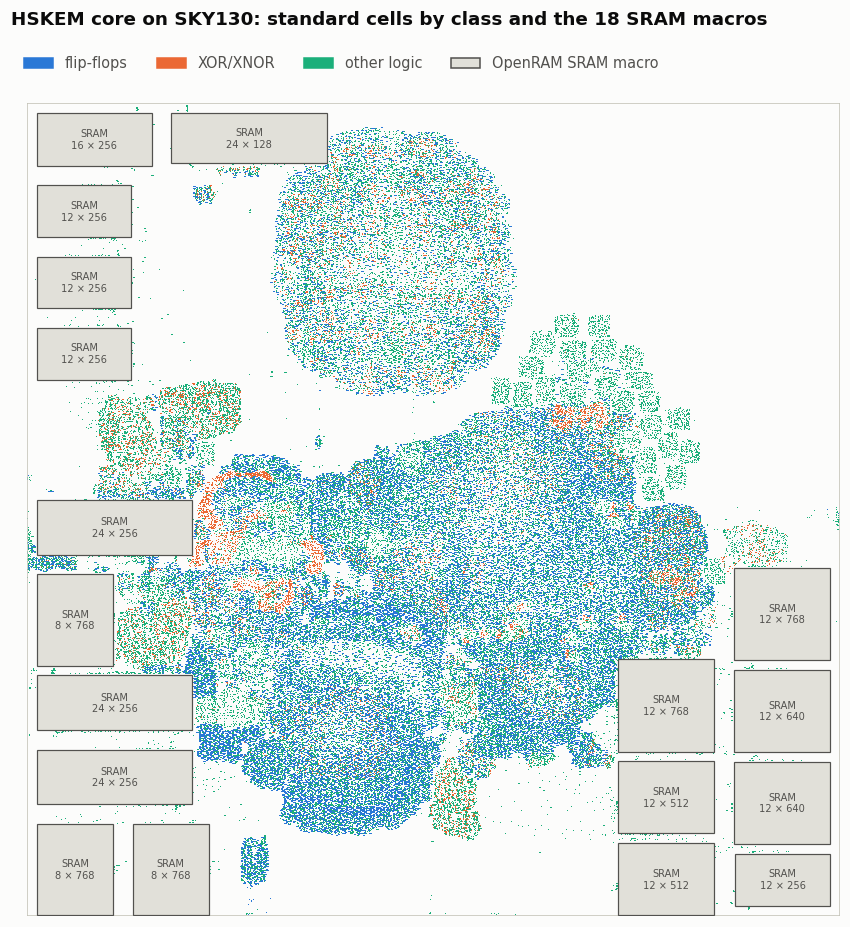

In [34]:
fc = json.loads((ROOT/"results/fullchip/summary.json").read_text())
m, s = fc["orfs_metrics"], fc["signoff"]
display(pd.Series({
    "die area [mm²]": m["finish__design__die__area"]/1e6,
    "std cells": m["finish__design__instance__count__stdcell"],
    "std-cell area [mm²]": m["finish__design__instance__area__stdcell"]/1e6,
    "SRAM macros": m["finish__design__instance__count__macros"],
    "SRAM area [mm²]": m["finish__design__instance__area__macros"]/1e6,
    "flip-flops": m["finish__design__instance__count__class:sequential_cell"],
    "clock target [ns]": fc["clock_target_ns"],
    "setup WNS [ns]": m["finish__timing__setup__ws"], "hold WNS [ns]": m["finish__timing__hold__ws"],
    "post-route fmax [MHz]": m["finish__timing__fmax"]/1e6,
    "LVS (primary / repeat)": f'{s["primary_compare"]} / {s["repeat_compare"]}',
    "LVS negative control detected": s["negative_control_detected"],
    "DRC markers (BEOL+offgrid deck)": s["drc_markers"],
}, name="HSKEM core"))
print("claim boundary:", s["claim_boundary"])
print("power:", fc["power"])
# the abstract quotes these two figures
assert m["finish__design__instance__count__stdcell"] > 320_000 and m["finish__design__instance__count__macros"] == 18
import placement_map as pm
from matplotlib.patches import Patch
fig, ax = plt.subplots(figsize=(8, 8.4))
pm.draw_chip(ax)
ax.set_position([0.02, 0.01, 0.96, 0.88])          # square die directly under the legend
fig.legend([Patch(color=c) for _, c in pm.CLASSES] + [Patch(facecolor="#e1e0d9", edgecolor=ps.INK_2)],
           [n for n, _ in pm.CLASSES] + ["OpenRAM SRAM macro"], ncols=4, loc="upper left",
           bbox_to_anchor=(0.02, 0.955), frameon=False)
fig.suptitle("HSKEM core on SKY130: standard cells by class and the 18 SRAM macros",
             x=0.02, ha="left", y=0.99, fontsize=12, fontweight="bold")
plt.show()

**The whole chip at three corners.** `scripts/sta_corners_fullchip.sh` repeats the corner analysis of
Section 6 for the routed chip, with its extracted parasitics. One restriction applies: OpenRAM
characterizes the SRAM macros at the typical corner only, so their typical views are used at every
corner, and only the flip-flop-to-flip-flop paths can be judged at the slow and fast corners. Only the
summary of this analysis is published, since the layout database is not.

In [35]:
fs = json.loads((ROOT/"results/fullchip/sta_corners.json").read_text())
CN = ["ss_100C_1v60", "tt_025C_1v80", "ff_n40C_1v95"]
fct = pd.DataFrame({c: {"reg→reg fmax [MHz]": fs["corners"][c]["reg2reg_fmax_mhz"],
                        "reg→reg hold slack [ns]": fs["corners"][c]["reg2reg_hold_slack_ns"],
                        "design setup WNS [ns]": fs["corners"][c]["setup_wns"],
                        "design hold WNS [ns]": fs["corners"][c]["hold_wns"],
                        "hold-violating endpoints": int(fs["corners"][c]["hold_violating_endpoints"])} for c in CN}).T
# paths through the macros use typical-corner views at every corner: the design-level slow-corner figures
# mix corners and are not shown
fct = fct.astype(object)
fct.loc["ss_100C_1v60", ["design setup WNS [ns]", "design hold WNS [ns]", "hold-violating endpoints"]] = "not meaningful (macro views: tt only)"
display(fct.rename_axis("corner"))
for c in ("tt_025C_1v80", "ff_n40C_1v95"):
    for v in fs["corners"][c]["hold_violators"]:
        print(f"{c}: {v['path']}, hold slack {1e3 * v['slack_ns']:.0f} ps")
# guards for the statements made in the text below
clk = fs["clock_period_ns"]
assert all(fs["corners"][c]["reg2reg_fmax_mhz"] > 1e3 / clk and fs["corners"][c]["reg2reg_hold_slack_ns"] > 0 for c in CN)
assert fs["corners"]["ss_100C_1v60"]["reg2reg_fmax_mhz"] > 2e3 / clk
tt_, ff_ = fs["corners"]["tt_025C_1v80"], fs["corners"]["ff_n40C_1v95"]
assert tt_["setup_wns"] > 4.5 and tt_["hold_violating_endpoints"] == 2 and tt_["hold_wns"] >= -0.05
assert ff_["setup_wns"] > 0 and ff_["hold_violating_endpoints"] == 1 and ff_["hold_wns"] >= -0.005
assert abs(m["finish__timing__hold__ws"] - 0.119) < 0.001

corner,reg→reg fmax [MHz],reg→reg hold slack [ns],design setup WNS [ns],design hold WNS [ns],hold-violating endpoints
"slow corner (ss, 100 °C, 1.60 V)",54.67,1.04,not meaningful (macro views: tt only),not meaningful (macro views: tt only),not meaningful (macro views: tt only)
"typical corner (tt, 25 °C, 1.80 V)",95.97,0.51,4.994,-0.042,2.0
"fast corner (ff, −40 °C, 1.95 V)",145.56,0.29,10.576,-0.001,1.0


tt_025C_1v80: input port (external delay assumed by the SDC) to an HSM response register, hold slack -40 ps
tt_025C_1v80: register to a PUF raw-capture register, hold slack -20 ps
ff_n40C_1v95: register to register inside the SPI frame buffer, hold slack -1 ps


Every flip-flop-to-flip-flop path of the chip meets the 40 ns clock at all three corners, with
positive hold slack; even at the slow corner these paths would support more than twice the 25 MHz
clock. At the typical corner the
whole design meets setup with about 5 ns to spare, and two endpoints miss hold by at most 40 ps: one
path starts at an input port, so its slack depends on the external delay assumed in the constraints,
and the other ends at a PUF capture register. ORFS's own final report of the same layout gives a worst
hold slack of +0.119 ns at the typical corner; the difference between the two analyses was not traced.
At the fast corner a single register-to-register path misses hold by 1 ps. The hold margin that
cleaned the NTT layouts in Section 6 is the natural remedy for these few paths, applied in a new run of
the chip.

The GDS of the same chip, rendered with KLayout and downscaled to about 2.5 µm per pixel: enough to show
the floorplan, with the SRAM macros along the left and right edges, but far too coarse to resolve any
individual cell or wire. The layout database itself is not published, because its logic contains the
demonstration board's provisioning test credential; its SHA-256 is recorded in `results/fullchip/`.

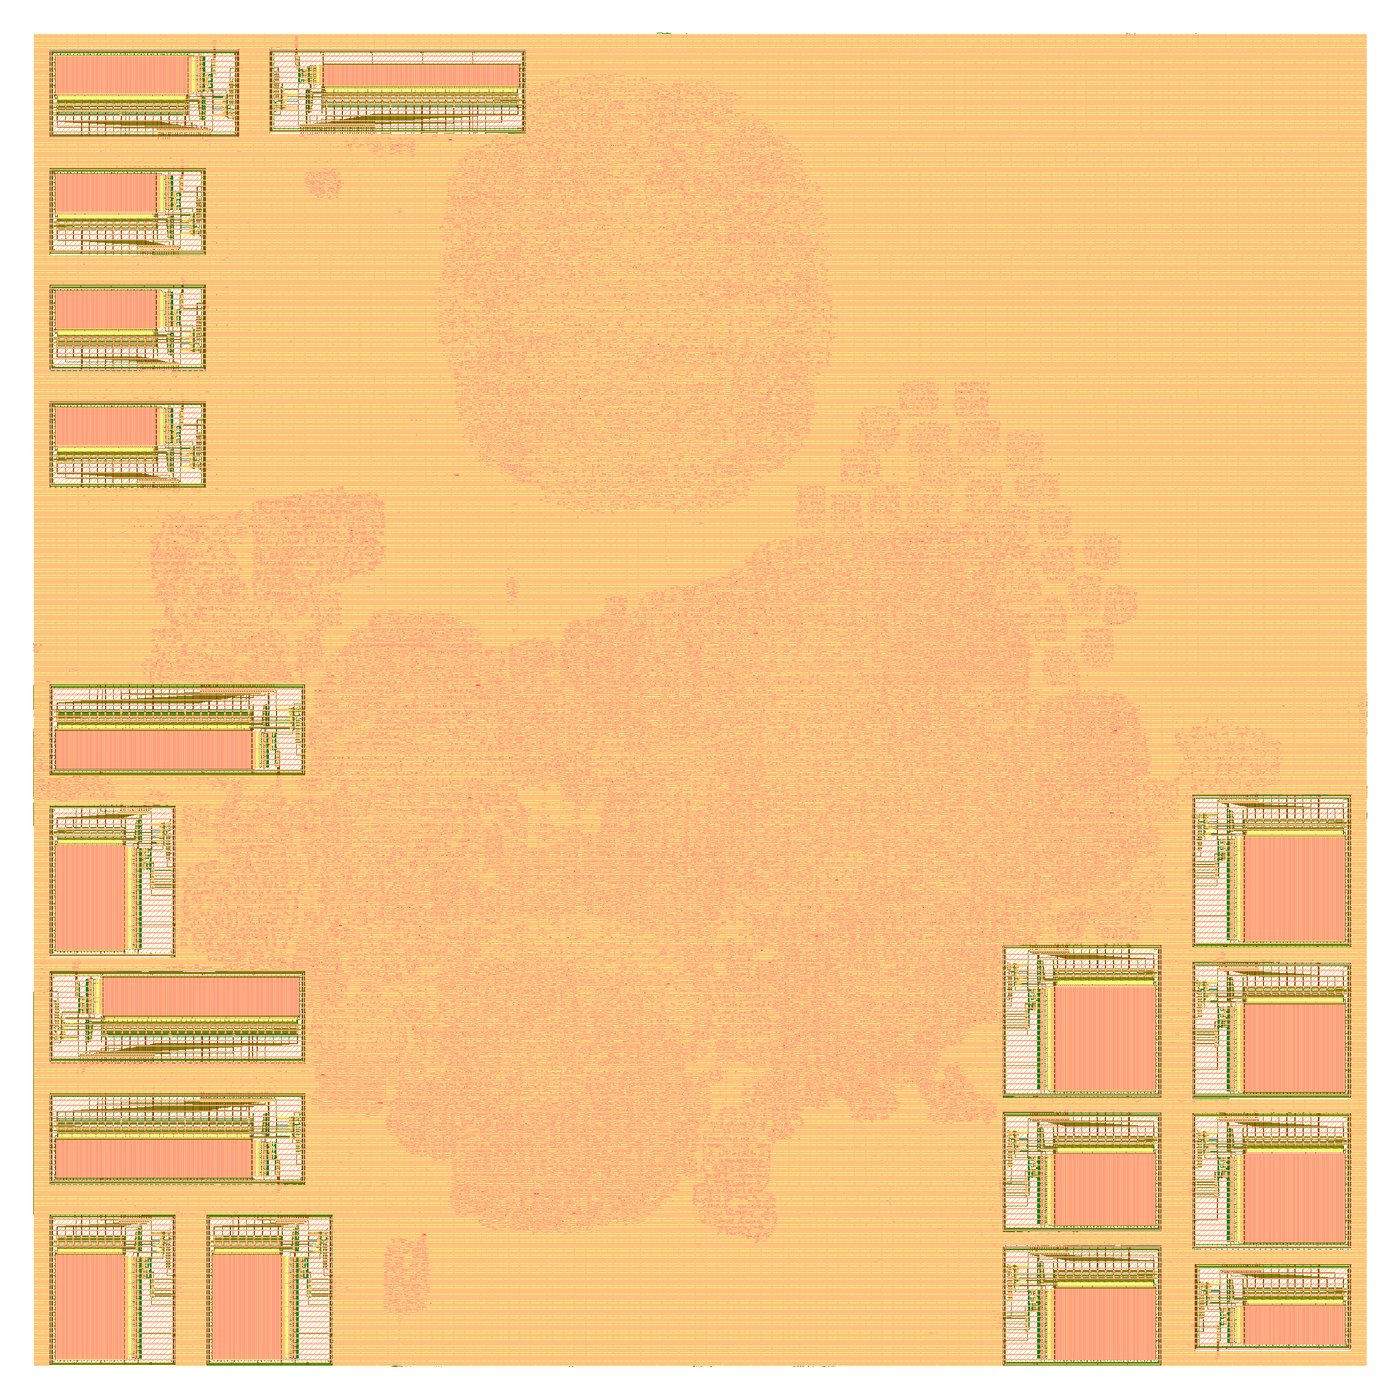

In [36]:
display(Image(str(ROOT/"figures/fullchip_layout.jpg"), width=640))

### Where the chip's area goes

The flow flattens the design, and synthesis gives most combinational cells generic names, but every
flip-flop and every SRAM macro keeps its hierarchical name. `scripts/fullchip_blocks.py` uses those names
to attribute the registers and the macros of the routed chip to the HSKEM blocks; only the resulting
counts are published (`results/fullchip/blocks.csv`). Combinational logic is not attributed.

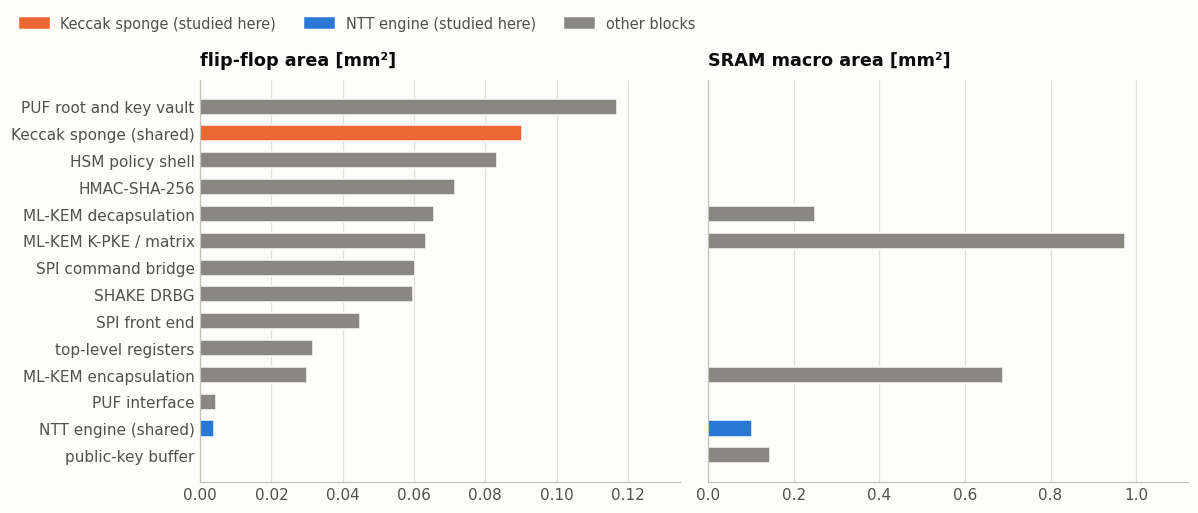

NTT engine: 154 flip-flops (0.5% of the flip-flop area) and one 4096-bit SRAM macro; Keccak sponge: 3606 flip-flops (12.4%) and no SRAM


In [37]:
blk = pd.read_csv(ROOT/"results/fullchip/blocks.csv").set_index("block")
# the attribution must account for the whole chip
assert abs(blk.flops.sum() - m["finish__design__instance__count__class:sequential_cell"]) <= 5
assert abs(blk.sram_area_um2.sum() - m["finish__design__instance__area__macros"]) / m["finish__design__instance__area__macros"] < 0.001
BLOCK = {"g_qualification_puf_vault": "PUF root and key vault", "u_shared_mlkem_sponge": "Keccak sponge (shared)",
         "u_hsm_shell": "HSM policy shell", "u_security_hmac": "HMAC-SHA-256", "u_mlkem512_decaps_partial": "ML-KEM decapsulation",
         "u_c2_shake_drbg": "SHAKE DRBG", "u_mlkem512_kpke_partial": "ML-KEM K-PKE / matrix", "u_bridge": "SPI command bridge",
         "u_spi": "SPI front end", "(top-level registers)": "top-level registers", "u_mlkem512_encaps_partial": "ML-KEM encapsulation",
         "u_puf": "PUF interface", "u_shared_ntt": "NTT engine (shared)", "u_c3_pk_pair_sram": "public-key buffer"}
blk.index = [BLOCK.get(b, b) for b in blk.index]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), sharey=True)
rows_ = blk.sort_values("flop_area_um2").index
hl = {"Keccak sponge (shared)": ps.SERIES[1], "NTT engine (shared)": ps.SERIES[0]}
for ax, col, title in [(axes[0], "flop_area_um2", "flip-flop area [mm²]"), (axes[1], "sram_area_um2", "SRAM macro area [mm²]")]:
    vals = blk.loc[rows_, col] / 1e6
    ax.barh(range(len(rows_)), vals, height=0.6, color=[hl.get(r, ps.MUTED) for r in rows_], edgecolor=ps.SURFACE)
    ax.set_title(title); ax.grid(axis="y", visible=False); ax.set_xlim(0, vals.max() * 1.15)
axes[0].set_yticks(range(len(rows_)), rows_)
fig.legend([Patch(color=c) for c in hl.values()] + [Patch(color=ps.MUTED)],
           ["Keccak sponge (studied here)", "NTT engine (studied here)", "other blocks"], ncols=3,
           loc="lower left", bbox_to_anchor=(0.01, 0.98), frameon=False)
ps.finish(fig); plt.show()
tot_ff = blk.flop_area_um2.sum()
print(f"NTT engine: {blk.loc['NTT engine (shared)', 'flops']:.0f} flip-flops "
      f"({blk.loc['NTT engine (shared)', 'flop_area_um2'] / tot_ff:.1%} of the flip-flop area) and one "
      f"{blk.loc['NTT engine (shared)', 'sram_bits']:.0f}-bit SRAM macro; "
      f"Keccak sponge: {blk.loc['Keccak sponge (shared)', 'flops']:.0f} flip-flops "
      f"({blk.loc['Keccak sponge (shared)', 'flop_area_um2'] / tot_ff:.1%}) and no SRAM")
assert blk.loc["NTT engine (shared)", "flop_area_um2"] / tot_ff < 0.01
assert blk.flops.rank(ascending=False)["Keccak sponge (shared)"] == 2

At chip level the two blocks studied in this notebook differ sharply. The NTT engine keeps its
coefficients in an SRAM macro, so its own registers are a negligible share of the chip; its store is one
of eighteen macros. The Keccak sponge, which holds its 1600-bit states in flip-flops, is the
second-largest register block of the whole chip. This is the area counterpart of the decapsulation
profile measured below: the block that dominates the latency occupies little logic, while the larger of
the two accounts for a modest share of the latency.

### What the two ASIC decisions cost at system level

Block-level numbers can mislead: a block that is nine times slower matters little if the system rarely
waits for it. The full-system testbench of HSKEM, which drives the co-processor through its SPI interface exactly
as the ESP32 host does, measures the internal busy interval of decapsulation directly, which the 16-bit hardware counter cannot report.
`scripts/run_system_sim.sh` runs it with Icarus Verilog in four configurations: the FPGA configuration,
each ASIC decision on its own, and both together. The FPGA-configuration result reproduces an earlier
ModelSim run of the same testbench exactly.

The complete HSKEM RTL needed for this testbench is published in `hskem_rtl/`. It differs from the
source tree only where documented in `hskem_rtl/PUBLICATION_PATCH.diff`: a synthesis-time provisioning
test credential that is still used by my demonstration board is replaced by a public placeholder, and
the testbench's two precomputed provisioning tags are recomputed for that placeholder with the same
HMAC-SHA-256 construction. The recomputation was validated by first reproducing the original tags from
the original credential. The published copy passes the complete testbench and yields the same
measurements.

,decapsulation cycles,Keccak permutations,shared-secret fingerprints,testbench result,decapsulation at 50 MHz [ms],change vs FPGA configuration
FPGA configuration,81457,26,['27033e5e'],ALL PASS (baseline + D1/D2 internal restore + HSM-4E auth + HSM-4F legacy lock),1.6291,0
row-serialized Keccak only,85201,26,['27033e5e'],FAIL (7 errors),1.7040,3744
single-port store only,95793,26,['27033e5e'],ALL PASS (baseline + D1/D2 internal restore + HSM-4E auth + HSM-4F legacy lock),1.9159,14336
ASIC configuration (both choices),99537,26,['27033e5e'],ALL PASS (baseline + D1/D2 internal restore + HSM-4E auth + HSM-4F legacy lock),1.9907,18080


published RTL copy (hskem_rtl/): ALL PASS, decapsulation 81,457 cycles
single-port store: +14336 cycles = 8 transforms x 896 butterflies x 2
row-serialized Keccak: +3744 cycles = 26 permutations x 144
the two effects add exactly: True
note on keccak_only: keccak_only is not a configuration the testbench's hard-coded cycle oracle supports: its 7 FAIL lines are cycle-count equality checks only; every digest and permutation count matches, and each measured count equals the FPGA oracle plus 144 cycles per Keccak permutation (KeyGen 35171+36*144=40355, Encaps 55692+20*144=58572, Encrypt 50449+7*144=51457).


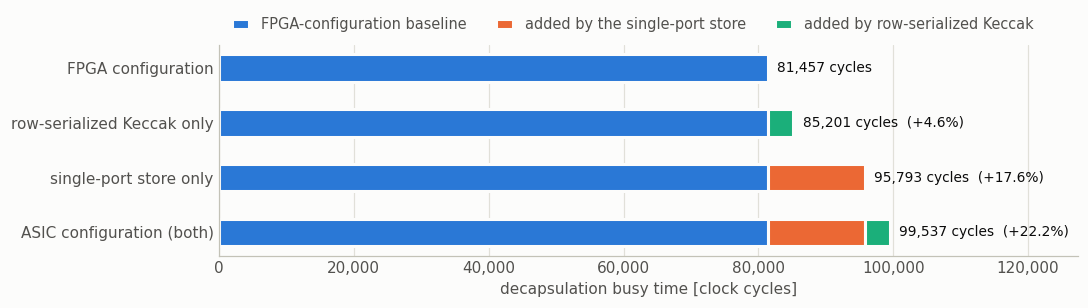

In [38]:
ss_ = json.loads((ROOT/"results/system_sim/summary.json").read_text())
cfg = pd.DataFrame(ss_["configs"]).T[["decaps_cycles", "decaps_keccak_permutations", "shared_secret_fingerprints", "tb_result"]]
cfg["decaps_ms_at_50MHz"] = cfg.decaps_cycles.astype(float) / 50e6 * 1e3
cfg["delta_vs_fpga"] = cfg.decaps_cycles.astype(int) - int(cfg.loc["fpga", "decaps_cycles"])
display(cfg)
dec = ss_["decomposition"]
assert dec["additive"] and dec["keccak_serial_delta"] == dec["keccak_serial_model"] \
       and dec["single_port_sram_delta"] == dec["single_port_sram_model"]
assert cfg.shared_secret_fingerprints.map(tuple).nunique() == 1, "configurations disagree on the shared key"
pc = ss_["published_copy_check"]
assert pc["tb_result"].startswith("ALL PASS") and pc["decaps_cycles"] == int(cfg.loc["fpga", "decaps_cycles"])
print(f"published RTL copy (hskem_rtl/): {pc['tb_result'][:8]}, decapsulation {pc['decaps_cycles']:,} cycles")
print(f"single-port store: +{dec['single_port_sram_delta']} cycles = 8 transforms x 896 butterflies x 2")
print(f"row-serialized Keccak: +{dec['keccak_serial_delta']} cycles = 26 permutations x 144")
print("the two effects add exactly:", dec["additive"])
print("note on keccak_only:", ss_["note_keccak_only"])

base = int(cfg.loc["fpga", "decaps_cycles"])
rows = [("FPGA configuration", 0, 0), ("row-serialized Keccak only", 0, dec["keccak_serial_delta"]),
        ("single-port store only", dec["single_port_sram_delta"], 0),
        ("ASIC configuration (both)", dec["single_port_sram_delta"], dec["keccak_serial_delta"])][::-1]
fig, ax = plt.subplots(figsize=(10, 2.9))
for y, (name, ntt_extra, kec_extra) in enumerate(rows):
    ax.barh(y, base, height=0.5, label="FPGA-configuration baseline" if y == 0 else None, **ps.bar_kw(ps.SERIES[0]))
    if ntt_extra:
        ax.barh(y, ntt_extra, left=base, height=0.5, label="added by the single-port store" if y == 0 else None, **ps.bar_kw(ps.SERIES[1]))
    if kec_extra:
        ax.barh(y, kec_extra, left=base + ntt_extra, height=0.5, label="added by row-serialized Keccak" if y == 0 else None, **ps.bar_kw(ps.SERIES[2]))
    total = base + ntt_extra + kec_extra
    ax.annotate(f"{total:,} cycles" + (f"  (+{total / base - 1:.1%})" if total > base else ""),
                (total, y), xytext=(6, 0), textcoords="offset points", va="center", fontsize=9, color=ps.INK)
ax.set_yticks(range(len(rows)), [r[0] for r in rows]); ax.grid(axis="y", visible=False)
ax.set_xlim(0, (base + dec["both_delta"]) * 1.28); ax.set_xlabel("decapsulation busy time [clock cycles]")
ps.thousands(ax)
ax.legend(ncols=3, loc="lower left", bbox_to_anchor=(0, 1.0), handlelength=1.2)
ps.finish(fig); plt.show()

Both decisions add latency to decapsulation, and their effects add exactly, as the analytical model
predicts. At system level the single-port coefficient store accounts for most of the difference, while
the row-serialized Keccak — nine times slower as a block — adds only a few percent. Valid and implicitly
rejected ciphertexts take the same number of cycles in every configuration, so decapsulation time does
not reveal whether a ciphertext was valid.

### Where decapsulation spends its cycles

The decomposition above is inferred from differences between configurations. To measure it directly, a
small monitor module, `tb/decaps_profiler.sv`, is simulated alongside the testbench. It only reads signals through hierarchical
references, so neither the published RTL nor the testbench changes, and it counts, cycle by cycle, whether
the shared NTT engine, the Keccak sponge and the permutation inside it are busy during a decapsulation.

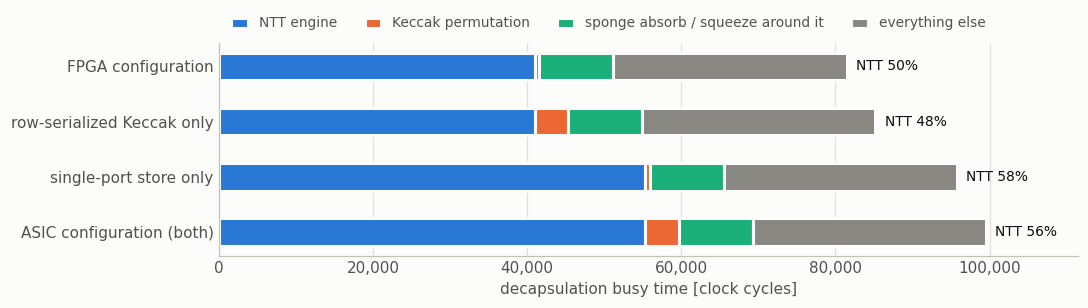

,NTT engine,Keccak permutation,sponge absorb / squeeze around it,everything else
FPGA configuration,0.503,0.008,0.118,0.372
row-serialized Keccak only,0.481,0.051,0.112,0.356
single-port store only,0.577,0.007,0.100,0.316
ASIC configuration (both),0.556,0.044,0.096,0.304


In [39]:
# True re-runs the profiled full-system simulation of the FPGA and ASIC configurations with Icarus
# Verilog (about five minutes, both in parallel; works in Colab); the two single-decision
# configurations are then read from the committed logs
RUN_SYSTEM_SIM = False
if RUN_SYSTEM_SIM:
    sh("for c in fpga asic; do CAC_PROFILE=1 CAC_SIM_TAG=_prof bash scripts/run_system_sim.sh $c & done; wait")
    sh("python3 scripts/collect_profile.py")
prof = json.loads((ROOT/"results/system_sim/decaps_profile.json").read_text())["configs"]
pf = pd.DataFrame({c: v["profile"] for c, v in prof.items()}).T
# the profile must reproduce the testbench's own latency and the decomposition above
assert (pf.cycles == cfg.loc[pf.index, "decaps_cycles"].astype(int)).all()
assert pf.ntt_and_sponge.eq(0).all(), "NTT and sponge were expected never to overlap"
assert pf.other.nunique() == 1 and pf.sponge_io.nunique() == 1, "the ASIC choices changed unrelated work"
assert pf.loc["sram_only", "ntt_busy"] - pf.loc["fpga", "ntt_busy"] == dec["single_port_sram_delta"]
assert pf.loc["keccak_only", "perm_busy"] - pf.loc["fpga", "perm_busy"] == dec["keccak_serial_delta"]
assert (pf.ntt_starts == 8).all() and (pf.ntt_inverse_starts == 4).all() and (pf.perm_starts == 26).all()
fp = pf.loc["fpga"]   # guards for the statements made in the text below
assert 0.45 < fp.ntt_busy / fp.cycles < 0.55 and fp.perm_busy / fp.cycles < 0.01
assert 15 < fp.sponge_busy / fp.perm_busy < 17.5 and 0.33 < fp.other / fp.cycles < 0.40

parts = [("ntt_busy", "NTT engine", ps.SERIES[0]), ("perm_busy", "Keccak permutation", ps.SERIES[1]),
         ("sponge_io", "sponge absorb / squeeze around it", ps.SERIES[2]), ("other", "everything else", ps.MUTED)]
names = {"fpga": "FPGA configuration", "keccak_only": "row-serialized Keccak only",
         "sram_only": "single-port store only", "asic": "ASIC configuration (both)"}
order = ["asic", "sram_only", "keccak_only", "fpga"]
fig, ax = plt.subplots(figsize=(10, 2.9))
for y, c in enumerate(order):
    left = 0
    for col, lab, colour in parts:
        ax.barh(y, pf.loc[c, col], left=left, height=0.5, label=lab if y == 0 else None, **ps.bar_kw(colour))
        left += pf.loc[c, col]
    ax.annotate(f"NTT {pf.loc[c, 'ntt_busy'] / pf.loc[c, 'cycles']:.0%}", (left, y), xytext=(6, 0),
                textcoords="offset points", va="center", fontsize=9, color=ps.INK)
ax.set_yticks(range(len(order)), [names[c] for c in order]); ax.grid(axis="y", visible=False)
ax.set_xlim(0, pf.cycles.max() * 1.12); ax.set_xlabel("decapsulation busy time [clock cycles]"); ps.thousands(ax)
ax.legend(ncols=4, loc="lower left", bbox_to_anchor=(0, 1.0), handlelength=1.2, fontsize=9)
ps.finish(fig); plt.show()
share = pf[[p[0] for p in parts]].div(pf.cycles, axis=0)
share.columns = [p[1] for p in parts]
share.rename(index=names).round(3)

The profile confirms the decomposition to the cycle and explains it. In the FPGA configuration the NTT
engine is busy for half of the decapsulation, whereas the Keccak permutation itself runs for less than one
percent of it. The sponge around the permutation, into and out of which data move one byte per
handshake, is busy roughly sixteen times longer than the permutation, and more than a third of the time
goes to the remaining work of the decapsulation datapath, during which neither block is active. Each ASIC
decision changes only its own share — the single-port store lengthens the NTT portion, the
row-serialized round the permutation — while everything else stays identical to the cycle. For this chip
a faster permutation is therefore worth little; a faster NTT or a wider sponge interface is the more
promising target.

## 8. The same RTL on hardware: DE25-Nano measurements

The same NTT and Keccak RTL, in its FPGA configuration (a dual-port M20K store and one Keccak round per
clock), runs inside HSKEM on the DE25-Nano at 50 MHz under the control of an ESP32 host over SPI. The
bitstream is the released demonstration build, which also contains a read-only signal observer for live
waveforms; its SHA-256 is recorded in `results/fpga/`. I executed
the complete two-role ML-KEM flow — key generation, public-key transfer, encapsulation, ciphertext
transfer, and an independent decapsulation that must reproduce the same shared secret — 100 times in
succession, logging the FPGA's own cycle counters alongside the latency measured by the ESP32
(`board/repeat_c3.py`; the raw UART log is in `results/fpga/`).

The released bitstreams deliberately disable the stand-alone NTT self-test command, so the NTT is
observed on hardware only as part of these complete flows; its isolated cycle count comes from
simulation (Section 4).

Two properties of these measurements deserve attention:
* The FPGA cycle counters are **16 bits wide and saturate at 65 535**. Decapsulation always saturates, so
  only a lower bound is known, and it is reported as such rather than extrapolated.
* Key-generation and encapsulation counts vary by a few cycles from run to run. This is expected:
  `SampleNTT` performs rejection sampling on the **public** seed ρ, so the variation reveals nothing secret.

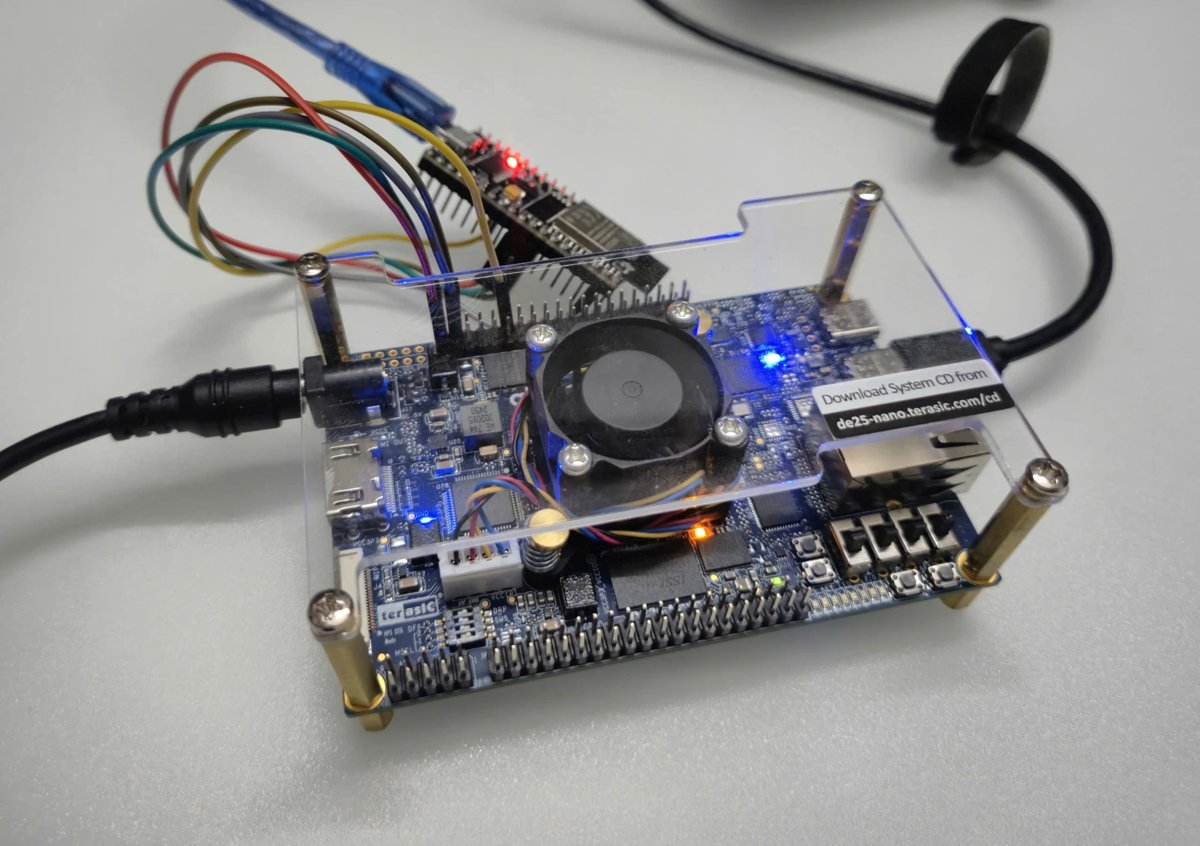

In [40]:
display(Image(str(ROOT/"results/fpga/board_setup.jpg"), width=620))

*The measurement setup. The DE25-Nano board (Altera Agilex 5, shown in an acrylic case with its cooling
fan) hosts HSKEM; the ESP32 development board at the rear acts as the untrusted host and reaches the
FPGA's GPIO header through the jumper wires that carry the SPI link.*

In [41]:
fr = json.loads((ROOT/"results/fpga/fpga_resources.json").read_text())
display(pd.DataFrame({k: v for k, v in fr.items() if isinstance(v, dict)}).T)
b = pd.read_csv(ROOT/"results/fpga/c3_repeat.csv")
F_CLK = 50e6
assert b.result_pass.all(), "a two-role ML-KEM run failed"
phases = ["keygen", "encaps", "ciphertext_final", "decaps"]
st = pd.DataFrame({p: {"min": b[f"{p}_cycles"].min(), "median": b[f"{p}_cycles"].median(),
                       "max": b[f"{p}_cycles"].max(),
                       "saturated": int((b[f"{p}_cycles"] >= 65535).sum())} for p in phases}).T
st["core_time_ms (at median)"] = st["median"] / F_CLK * 1e3
st["note"] = ["counter saturated: lower bound only" if s else "" for s in st["saturated"]]
display(st)
core_ms = st.loc[["keygen","encaps","ciphertext_final","decaps"], "median"].sum() / F_CLK * 1e3
e2e_ms = b.esp32_latency_us.median() / 1e3
print(f"runs: {len(b)}  all PASS: {bool(b.result_pass.all())}  shared-secret match in every run")
print(f"end-to-end C3 latency seen by the ESP32: median {e2e_ms:.1f} ms  (min {b.esp32_latency_us.min()/1e3:.1f}, max {b.esp32_latency_us.max()/1e3:.1f})")
print(f"FPGA core time (lower bound, decaps saturated): {core_ms:.2f} ms  ->  {100*core_ms/e2e_ms:.3f} % of the end-to-end time")
# guards for the statements made in the text below
ntt_fpga = fr["kyber_ntt_engine (u_shared_ntt)"]
assert 100 < float(ntt_fpga["alms_needed"].split()[0]) < 1000
assert (ntt_fpga["m20k"], ntt_fpga["dsp"], ntt_fpga["block_memory_bits"]) == ("1", "2", "3072")
assert core_ms / e2e_ms < 0.01, "the core no longer accounts for well under one percent"

# effective throughput of the host link: payload bytes moved per run (public key and ciphertext,
# each exported and imported once) over the end-to-end time, read from the raw log of every run
raw = (ROOT/"results/fpga/c3_repeat_raw.log").read_text()
moved = [sum(int(x) for x in re.findall(r"C3_(?:PUBLIC_KEY|CIPHERTEXT)_(?:EXPORT|IMPORT): PASS chunks=\d+ bytes=(\d+)", run))
         for run in raw.split("### run ")[1:]]
assert len(moved) == len(b) and set(moved) == {3136}
tput = 3136 / (b.esp32_latency_us / 1e6)
print(f"payload over the host link: 3,136 bytes per run; effective throughput median {tput.median():.0f} B/s "
      f"(range {tput.min():.1f}-{tput.max():.1f}); end-to-end spread {b.esp32_latency_us.max() - b.esp32_latency_us.min():.0f} us")
assert 300 < tput.median() < 450 and b.esp32_latency_us.max() - b.esp32_latency_us.min() < 1000

,ALMs,registers,block-memory bits,M20K blocks,DSP blocks
NTT engine,375.3 (255.6),176 (176),3072,1,2
Keccak permutation (one round per clock),1881.5 (1881.5),1997 (1997),0,0,0
"Keccak sponge, including the permutation",4008.2 (2126.7),4046 (2049),0,0,0


,min,median,max,saturated runs,core time at median [ms],note
key generation,35640,35655,35670,0,0.7131,
encapsulation,56157,56171,56188,0,1.1234,
ciphertext finalization,6148,6148,6148,0,0.1230,
decapsulation,65535,65535,65535,100,1.3107,counter saturated: lower bound only


runs: 100  all PASS: True  shared-secret match in every run
end-to-end C3 latency seen by the ESP32: median 8625.3 ms  (min 8625.0, max 8625.7)
FPGA core time (lower bound, decaps saturated): 3.27 ms  ->  0.038 % of the end-to-end time
payload over the host link: 3,136 bytes per run; effective throughput median 364 B/s (range 363.6-363.6); end-to-end spread 628 us


**HSM security invariants on hardware.** The same board then exercised the HSM's frame-protection
invariants 100 times, using a banking transaction as the test scenario. Each run establishes a fresh
ML-KEM session whose shared key never leaves the FPGA and submits one authenticated frame. It then
confirms that a copy of that frame with the amount altered by a single unit is rejected (`AUTH_FAILED`),
that a replay of the accepted frame is rejected (`REPLAY_DETECTED`), and that after a zeroize any further
frame is refused (`AUTH_REQUIRED`). This is a regression test of the intended behaviour on one board
with fixed test patterns; it is not a security evaluation.

In [42]:
bank = pd.read_csv(ROOT/"results/fpga/bank_repeat.csv")
marks = [c for c in bank.columns if c.startswith("bank_")]
summary = pd.DataFrame({m: bank[m].value_counts() for m in marks}).fillna(0).astype(int).T
display(summary)
print("runs:", len(bank), " duplicate debits:", int(bank.duplicate_debit.sum()),
      " runs with any FAIL/failed text:", int(bank.any_fail_text.sum()))
assert (bank[marks] == "PASS").all().all() and bank.duplicate_debit.sum() == 0

,runs passed
ML-KEM session established,100
authenticated frame prepared,100
altered amount rejected,100
genuine frame accepted,100
replayed frame rejected,100
zeroize executed,100
frame after zeroize refused,100
complete scenario,100


runs: 100  duplicate debits: 0  runs with any FAIL/failed text: 0


**Where the time goes.** On this prototype the cryptography is not the bottleneck. The four FPGA phases
together take a few milliseconds, whereas the host observes several seconds, because the ESP32 transfers
the 800-byte public key and the 768-byte ciphertext over a deliberately slow bit-banged SPI link with a
nominal SCK of about 10 kHz, chosen for robustness during demonstrations. Measured end to end, the link
moves the 3,136 payload bytes of a run (public key and ciphertext, each exported and imported) at an
effective rate of about 0.36 kB/s, framing, responses and host-side processing included, with a
run-to-run spread of well under a millisecond. The clock frequency itself has not been measured, which
would take a logic analyzer. The next meaningful speed-up must therefore come from the
interface — a hardware SPI port, or keeping both roles on chip — rather than from a faster NTT.

**FPGA versus SKY130.** On the FPGA the NTT occupies a few hundred ALMs, one M20K block and two DSP
blocks, and Quartus stores only 12 bits per coefficient (3072 bits in total) because the upper four bits
are provably zero in the integrated design. The original block-level SKY130 runs keep a 16-bit store,
since the block's write port is 16 bits wide; the design iteration of Section 6b applies the same
narrowing to the ASIC store.

## 9. What is not yet protected: a simulated leakage assessment

**Timing.** Section 4 showed that the latency of both blocks is identical for every input, so neither
has a data-dependent timing channel, and Section 7 showed that decapsulation time does not reveal whether
a ciphertext was valid.

**Power.** To determine whether the datapath's switching activity depends on the data,
`tb/tb_ntt_leak.sv` records, for every cycle of a forward NTT, the Hamming distance between consecutive
values of the datapath registers — the standard register-transition power model. `golden/leakage.py`
then performs a fixed-versus-random TVLA [6]: one fixed polynomial is compared with fresh random ones in a
randomly interleaved sequence, with Gaussian noise added to model measurement noise. A value of
$|t| > 4.5$ indicates detectable leakage.

A **negative control** splits the random class into two halves. Because both halves are drawn from the
same distribution, the control must *not* cross the threshold; if it did, the leakage would originate in
the test setup rather than in the design.

This is a pre-silicon model rather than a measurement: it shows *where* data-dependent switching occurs,
not how many physical traces an attack would require.

**A first-order countermeasure.** Because the NTT is linear, it can be masked at the algorithm level
without changing the hardware, as in earlier masked lattice implementations [7]. The secret polynomial
$a$ is split into two arithmetic shares $(a - m,\ m)$ with a fresh uniform mask $m$, the engine
transforms each share, and $\mathrm{NTT}(a) = \mathrm{NTT}(a - m) + \mathrm{NTT}(m)$. Each share on its
own is uniformly distributed and independent of $a$. The same TVLA is then applied to the two
consecutive transforms as one trace. The committed results use 2000 traces per experiment; the Colab
default of 400 is faster and leads to the same conclusions.

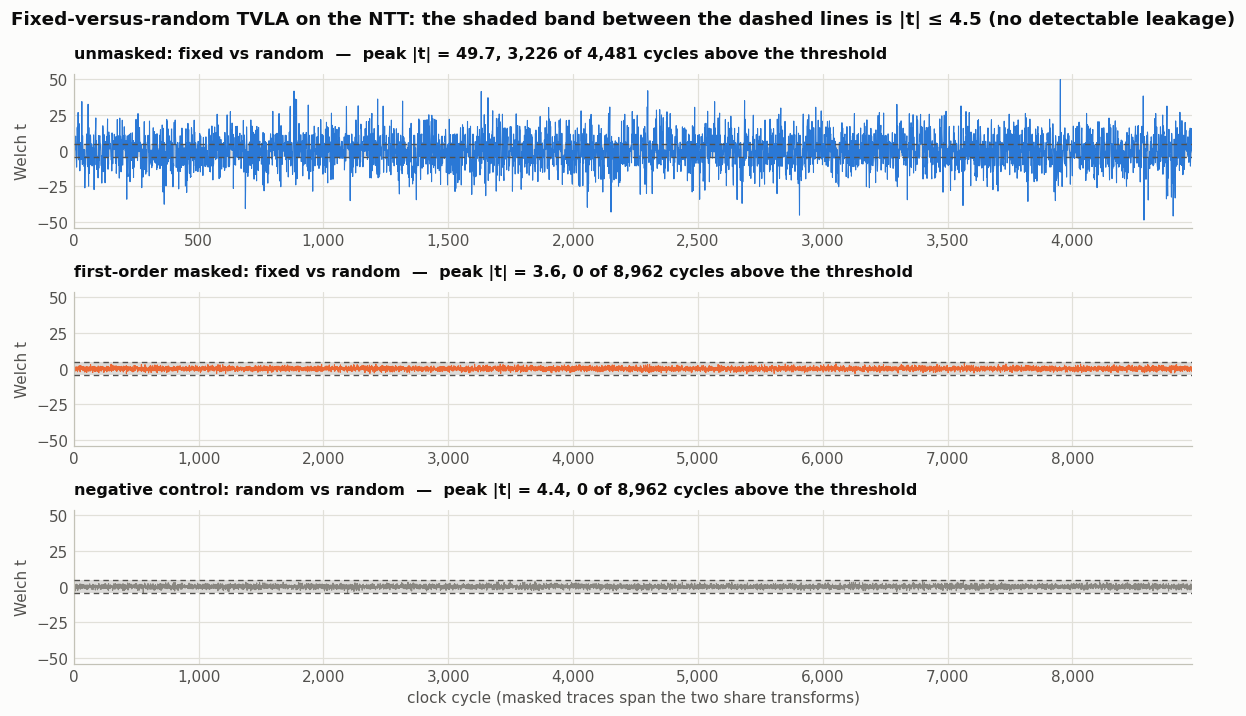

,traces,runs per trace,peak |t|,cycles with |t| > 4.5,share of cycles with |t| > 4.5,negative control: peak |t|,negative control: cycles with |t| > 4.5
unmasked,2000,1,49.7495,3226,0.7199,3.4338,0
first-order masked,2000,2,3.6362,0,0.0000,4.3507,0


In [43]:
LEAK_N = 400
if IN_COLAB:
    sh(f"bash scripts/run_leakage.sh {LEAK_N} 4.0 plain")
    sh(f"bash scripts/run_leakage.sh {LEAK_N} 4.0 masked")
summ, series = {}, []
for name, d in [("unmasked", "leakage"), ("first-order masked", "leakage_masked")]:
    summ[name] = json.loads((ROOT/"results"/d/"tvla_summary.json").read_text())
    series.append((f"{name}: fixed vs random", np.load(ROOT/"results"/d/"tvla_t.npy"), ps.SERIES[0 if name == "unmasked" else 1]))
series.append(("negative control: random vs random", np.load(ROOT/"results/leakage_masked/tvla_t_control.npy"), ps.MUTED))

ylim = max(np.abs(s[1]).max() for s in series) * 1.08
fig, axes = plt.subplots(3, 1, figsize=(11, 6.6), sharey=True)
for ax, (title, t, colour) in zip(axes, series):
    ax.axhspan(-4.5, 4.5, color=ps.MUTED, alpha=0.28, zorder=0, lw=0)  # the "no detectable leakage" band
    ax.plot(t, lw=0.7, color=colour, zorder=2)
    for y in (4.5, -4.5):                           # thresholds stay visible above the trace
        ax.axhline(y, color=ps.INK_2, lw=0.9, ls=(0, (4, 3)), zorder=3)
    ax.set_ylim(-ylim, ylim); ax.set_xlim(0, len(t)); ax.set_ylabel("Welch t"); ps.thousands(ax)
    over = int((np.abs(t) > 4.5).sum())
    ax.set_title(f"{title}  —  peak |t| = {np.abs(t).max():.1f}, {over:,} of {len(t):,} cycles above the threshold",
                 fontsize=10.5)
axes[-1].set_xlabel("clock cycle (masked traces span the two share transforms)")
fig.suptitle("Fixed-versus-random TVLA on the NTT: the shaded band between the dashed lines is |t| ≤ 4.5 (no detectable leakage)",
             x=0.01, ha="left", fontsize=12, fontweight="bold")
fig.tight_layout(); plt.show()
S = pd.DataFrame(summ).T[["traces", "runs_per_trace", "max_abs_t", "cycles_over_4p5",
                          "fraction_over_4p5", "control_max_abs_t", "control_cycles_over_4p5"]]
assert (S.control_cycles_over_4p5 == 0).all(), "negative control failed"
assert S.loc["unmasked", "cycles_over_4p5"] > 0 and S.loc["first-order masked", "cycles_over_4p5"] == 0
assert summ["first-order masked"]["cycles"] == 2 * summ["unmasked"]["cycles"]   # "twice the transform time"
S

Without masking, most cycles of the transform exceed the threshold by a wide margin. With first-order
masking no cycle crosses it, and the peak $|t|$ stays at the level of the negative control, which is what
a leak-free trace set produces. The price is twice the transform time. This establishes first-order
resistance only within the register-transition model; higher-order attacks, glitches and physical power
measurements lie outside its scope.

## 10. Findings

The next cell derives the ratios behind each finding from the post-route table and asserts the direction
of every claim made in the text that follows, so that the prose cannot silently diverge from the data.

In [44]:
P = pnr[pnr.clk_target_ns == 20].set_index("variant")   # the common 20 ns comparison point
def ratio(col, a, b): return P.loc[a, col] / P.loc[b, col]
F = pd.Series({
    "NTT dual/single: cell area":       ratio("cell_area_um2", "ntt_dp", "ntt_sp"),
    "NTT dual/single: latency":         ratio("latency_us_at_fmax", "ntt_dp", "ntt_sp"),
    "NTT dual/single: area x time":     ratio("at_product", "ntt_dp", "ntt_sp"),
    "Keccak serial/round: cell area":   ratio("cell_area_um2", "keccak_s7", "keccak_r1"),
    "Keccak serial/round: die area":    ratio("die_area_um2", "keccak_s7", "keccak_r1"),
    "Keccak serial/round: fmax":        ratio("fmax_mhz", "keccak_s7", "keccak_r1"),
    "Keccak serial/round: latency":     ratio("latency_us_at_fmax", "keccak_s7", "keccak_r1"),
    "Keccak serial/round: area x time": ratio("at_product", "keccak_s7", "keccak_r1"),
}).round(3)
assert F["NTT dual/single: latency"] < 1 < F["NTT dual/single: cell area"]
assert abs(F["NTT dual/single: area x time"] - 1) < 0.05
assert F["Keccak serial/round: cell area"] > 0.95 and 8.5 < F["Keccak serial/round: latency"] < 10  # "roughly nine times"
# every routed block-level layout, including the clock-sweep points, must be fully clean
assert (pnr.drc_errors == 0).all(), "a routed layout has DRC errors"
assert (pnr.antenna_violating_nets == 0).all(), "a routed layout has antenna violations"
# system level (Section 7): share of the decapsulation slowdown caused by each decision
sys_total = dec["both_delta"]
F["System: Decaps slowdown, both decisions"] = round(sys_total / int(cfg.loc["fpga", "decaps_cycles"]), 3)
F["System: share due to single-port store"] = round(dec["single_port_sram_delta"] / sys_total, 3)
F["System: share due to row-serial Keccak"] = round(dec["keccak_serial_delta"] / sys_total, 3)
assert F["System: share due to single-port store"] > 0.5 > F["System: share due to row-serial Keccak"]
assert dec["keccak_serial_delta"] / int(cfg.loc["fpga", "decaps_cycles"]) < 0.1   # "only a few percent"
assert 0.11 < pf.loc["fpga", "sponge_busy"] / pf.loc["fpga", "cycles"] < 0.14      # "about an eighth"
# design iteration (Section 6b), post-route, final iteration vs the original single-port NTT
F["Iteration (routed): cell area"] = round(it.loc["ntt_opt_pipe_w12", "cell_area_um2"] / base_it.cell_area_um2, 3)
F["Iteration (routed): fmax"] = round(it.loc["ntt_opt_pipe_w12", "fmax_mhz"] / base_it.fmax_mhz, 3)
F["Iteration (routed): latency"] = round(it.loc["ntt_opt_pipe_w12", "latency_us_at_fmax"] / base_it.latency_us_at_fmax, 3)
F["Iteration (routed): area x time"] = round(it.loc["ntt_opt_pipe_w12", "at_product"] / base_it.at_product, 3)
assert F["Iteration (routed): cell area"] < 0.85 and F["Iteration (routed): latency"] < 0.75 \
       and F["Iteration (routed): fmax"] > 1.5 and F["Iteration (routed): area x time"] < 0.6
print("NTT fmax [MHz]:", P.loc[["ntt_dp","ntt_sp"], "fmax_mhz"].round(1).to_dict())
F

NTT fmax [MHz]: {'ntt_dp': 47.5, 'ntt_sp': 49.8}


NTT dual/single: cell area                 1.333
NTT dual/single: latency                   0.748
NTT dual/single: area x time               0.997
Keccak serial/round: cell area             0.986
Keccak serial/round: die area              0.965
Keccak serial/round: fmax                  0.719
Keccak serial/round: latency               9.405
Keccak serial/round: area x time           9.272
System: Decaps slowdown, both decisions    0.222
System: share due to single-port store     0.793
System: share due to row-serial Keccak     0.207
Iteration (routed): cell area              0.786
Iteration (routed): fmax                   1.658
Iteration (routed): latency                0.689
Iteration (routed): area x time            0.542
dtype: float64

* **Correctness is established independently of the RTL.** The golden model agrees with a schoolbook
  product, with `kyber-py` and with `hashlib`, and as a complete ML-KEM-512 it reproduces every official
  NIST ACVP vector; the complete co-processor RTL reproduces all 25 NIST key-generation vectors byte for
  byte. The RTL matches the golden model on every coefficient and visits the butterflies in
  FIPS 203 order, its cycle counts equal the analytical model exactly, the on-chip self-test constant
  equals the golden fingerprint, the modular reducer is proven correct for all of its inputs, and every
  routed netlist simulated at gate level reproduces the golden results.
* **NTT: the single-port store costs nothing in area–time at block level.** It needs seven rather than
  five cycles per butterfly, but after routing the dual-port store is both larger and slightly slower to
  clock, so the two variants finish within a few percent of each other in area × time. Replacing the
  flip-flop store by the chip's OpenRAM macro then saves about a third of the block's area at a
  nearly unchanged clock. At system level, however, the extra cycles of the single-port store are the main
  source of the ASIC's slower decapsulation.
* **Keccak: a block-level loss that barely matters at system level.** Row-serialization saves only a few
  percent of area while making each permutation roughly nine times slower and five and a half times more
  energy-hungry, yet it adds only a few percent to decapsulation, because the permutation itself is busy
  for less than one percent of that operation. The choice is therefore close to neutral for the chip, and
  the one-round-per-clock core remains the better default.
* **Block-level figures of merit mislead unless they are weighed by use.** The cycle profile of Section 7
  measures how often the system waits for each block — the NTT for half of a decapsulation, the byte-wide
  sponge interface for about an eighth, the permutation for less than one percent — and the chip-level
  area attribution shows the mirror image: the latency-critical NTT occupies little logic, whereas the
  Keccak sponge is the second-largest register block of the chip.
* **The measurements pay for themselves.** They exposed two redundant reduction stages, four always-zero
  storage bits and a critical path that a single pipeline register splits. After place-and-route, the
  resulting iteration of the NTT is about a fifth smaller, clocks about two thirds faster, completes a
  transform about 30% sooner and roughly halves the area–time product, with clean DRC and antenna checks.
  Measured-activity power adds the counterweight: the 12-bit store alone saves about a fifth of the energy
  per transform, whereas the pipeline register gives back part of that saving in exchange for its speed.
* **The interface, not the arithmetic, limits the prototype.** On the FPGA board the cryptographic core
  accounts for well under one percent of the end-to-end latency; the slow host link accounts for the rest.
* **Security.** The NTT and Keccak blocks run in constant time, and decapsulation takes the same time for
  valid and rejected ciphertexts. The unprotected NTT leaks under the register-transition model, and
  algorithm-level first-order masking removes all first-order leakage at twice the transform time.

### Context: published Kyber hardware

HSKEM's NTT was designed for minimal area and a simple controller, not for speed, and the comparison
below with two published, peer-reviewed designs makes that trade-off explicit. The published figures
are copied from the cited papers; they refer to different platforms, clock rates and, for Sapphire, to
the round-1 version of Kyber ($q = 7681$, a full 256-point NTT), so the table gives orders of magnitude
rather than a ranking.

In [45]:
fp_c = cfg.loc["fpga", "decaps_cycles"]
# the published figures are quoted from the cited papers; the HSKEM rows are read from this notebook's results
ctx = pd.DataFrame([
    {"design": "HSKEM, FPGA configuration (this work)", "platform": "Agilex 5 FPGA, 50 MHz",
     "cycles / NTT": int(sim.loc["ntt_dp", "cycles_measured"]), "cycles / decapsulation": f"{int(fp_c):,}",
     "resources": f"NTT engine: {fr['kyber_ntt_engine (u_shared_ntt)']['alms_needed'].split()[0]} ALMs, 1 M20K, 2 DSP"},
    {"design": "HSKEM, NTT redesign (this work)", "platform": f"SKY130, {P.loc['ntt_opt_pipe_w12', 'fmax_mhz']:.1f} MHz",
     "cycles / NTT": int(P.loc["ntt_opt_pipe_w12", "cycles"]), "cycles / decapsulation": "–",
     "resources": f"NTT block: {P.loc['ntt_opt_pipe_w12', 'cell_area_um2'] / 1e6:.3f} mm² (flip-flop store)"},
    {"design": "Xing and Li, TCHES 2021 [13]", "platform": "Artix-7 FPGA, 161 MHz",
     "cycles / NTT": 448, "cycles / decapsulation": "6,668 (k = 2)",
     "resources": "complete KEM: 7,412 LUTs, 2 DSP, 3 BRAM"},
    {"design": "Sapphire, TCHES 2019 [14]", "platform": "TSMC 40 nm, 72 MHz",
     "cycles / NTT": 1289, "cycles / decapsulation": "–",
     "resources": "processor core: 0.28 mm² (Kyber round 1, q = 7681)"},
]).set_index("design")
ctx

design,platform,cycles / NTT,cycles / decapsulation,resources
"HSKEM, FPGA configuration (this work)","Agilex 5 FPGA, 50 MHz",4482,"81,457","NTT engine: 375.3 ALMs, 1 M20K, 2 DSP"
"HSKEM, NTT redesign (this work)","SKY130, 82.5 MHz",7170,–,NTT block: 0.170 mm² (flip-flop store)
"Xing and Li, TCHES 2021 [13]","Artix-7 FPGA, 161 MHz",448,"6,668 (k = 2)","complete KEM: 7,412 LUTs, 2 DSP, 3 BRAM"
"Sapphire, TCHES 2019 [14]","TSMC 40 nm, 72 MHz",1289,–,"processor core: 0.28 mm² (Kyber round 1, q = 7681)"


In cycles per transform, the published designs are several times to an order of magnitude ahead,
because they complete
at least one butterfly per clock where HSKEM's single datapath needs five to seven. Sapphire is
particularly instructive for this notebook: it too stores its coefficients in single-port SRAMs, but
spreads them over several banks so that the two operands and the two results of a butterfly never
compete for one port [14]. Combined with the cycle profile of Section 7, in which the NTT occupies half
of a decapsulation, this identifies the next step for HSKEM: a banked single-port store would remove the
two-cycle penalty that the chip's single-port macro costs today, and a deeper butterfly pipeline would
approach one butterfly per clock.

## 11. Limitations and reproducibility

**Limitations.** This work is pre-silicon: nothing has been fabricated. The golden model passes every
official NIST ACVP vector for ML-KEM-512 and the complete RTL reproduces all 25 key-generation vectors
byte for byte, but the design holds no CAVP or CMVP certificate, which only an accredited laboratory can
issue.
The full-chip DRC ran the BEOL and off-grid rules of the standard deck with FEOL checks disabled, and the
top-level LVS abstracts the SRAMs, which are verified separately at transistor level. Full-chip power is
omitted because the SRAM power model produced non-physical values; block-level power is derived from
gate-level switching activity for the NTT and Keccak blocks at the typical corner; five random inputs per
block agree to within half a percent. Timing closure was performed at the typical corner: the slow corner roughly halves every block's
frequency, and the NTT layouts show hold violations of up to 14 ps at the fast corner, which a hold
margin removes in every NTT layout at negligible cost (Section 6). At chip level, the SRAM macros
have typical-corner views only, so only the flip-flop paths are checked at every corner, and a handful
of paths miss hold by at most 40 ps (Section 7). The architectural
comparisons use a common 20 ns clock target, and the post-route clock sweep covers 7 to 30 ns for
selected blocks only. Apart from the macro-store point of Section 6, the block-level experiments use
flip-flop memories, whereas the full chip uses OpenRAM macros; the macro point is compared on area and
timing only, and its layout keeps marginal max-slew violations at the macro's address pins, 0.05 to
0.07 ns against the 0.04 ns end of the macro's characterization table (Section 6). Every block-level layout, including all clock-sweep points, is free of DRC and antenna
violations. The leakage assessment is a register-transition model, not a power measurement. The PUF and
entropy sources are ring oscillators on the FPGA; on the ASIC they are service interfaces rather than
on-silicon sources. The FPGA measurements come from a single board.

**Reproducing the results.** Sections 2 to 5, 6b and 9 run in Colab, including the gate-level simulation
of a routed netlist. Place-and-route (Section 6) is regenerated by setting `RUN_PNR = True` on Linux with
OpenROAD-flow-scripts at commit `6101364b`, or, without any installation, with the relocatable archive of
that exact build (`RUN_PNR_COLAB = True`, also in Colab), which reproduced every final metric of three
committed layouts in a clean Ubuntu 22.04 container (Section 6). The corner analysis is rerun with
`scripts/sta_corners.sh`, and the activity-based power of the routed blocks with
`scripts/run_gls_power.sh` and `scripts/run_gls_power_keccak.sh`, both of which read the parasitics of a
local ORFS run. The system-level simulation of Section 7 runs from the published RTL in `hskem_rtl/`
with `scripts/run_system_sim.sh` (about six minutes per configuration; `CAC_PROFILE=1` adds the cycle
profiler); setting `RUN_SYSTEM_SIM = True` repeats it inside the notebook, also in Colab, and its logs
and summaries are provided in `results/system_sim/`. Section 8 reports hardware
measurements whose raw logs and hashes are provided in `results/fpga/`. All RTL in `rtl/` is copied from
the HSKEM source tree by `scripts/sync_rtl.sh`; `rtl/UPSTREAM_SHA256.txt` records the upstream hashes,
and `rtl/PORTABILITY_PATCH.diff` documents the single change — an explicit `kyber_pkg::` scope — required
by older Icarus Verilog releases.

**Reuse.** No existing notebook was reused. Apart from the third-party material listed in `NOTICE` (the
SKY130 cell models and the NIST ACVP vectors) and the OpenRAM views of the chip's own SRAM macro, all
code in this folder was written for this project.

### References
1. NIST, FIPS 203, *Module-Lattice-Based Key-Encapsulation Mechanism Standard*, 2024.
2. NIST, FIPS 202, *SHA-3 Standard: Permutation-Based Hash and Extendable-Output Functions*, 2015.
3. NIST, ACVP-Server test vectors for ML-KEM, https://github.com/usnistgov/ACVP-Server.
4. G. Bertoni, J. Daemen, M. Peeters, G. Van Assche, *The Keccak reference*, version 3.0, 2011.
5. P. Barrett, "Implementing the Rivest Shamir and Adleman public key encryption algorithm on a standard
   digital signal processor", *Advances in Cryptology — CRYPTO '86*, Springer, 1987.
6. G. Goodwill, B. Jun, J. Jaffe, P. Rohatgi, "A testing methodology for side-channel resistance
   validation", NIST Non-Invasive Attack Testing Workshop, 2011.
7. O. Reparaz, S. Sinha Roy, F. Vercauteren, I. Verbauwhede, "A masked ring-LWE implementation",
   *Cryptographic Hardware and Embedded Systems — CHES 2015*, Springer, 2015.
8. T. Ajayi et al., "Toward an open-source digital flow: first learnings from the OpenROAD project",
   *Design Automation Conference (DAC)*, 2019; OpenROAD-flow-scripts,
   https://github.com/The-OpenROAD-Project/OpenROAD-flow-scripts.
9. M. R. Guthaus et al., "OpenRAM: an open-source memory compiler", *International Conference on
   Computer-Aided Design (ICCAD)*, 2016.
10. SkyWater Technology and Google, SKY130 open-source PDK, https://github.com/google/skywater-pdk.
11. YosysHQ, Yosys and the OSS CAD Suite, https://github.com/YosysHQ/oss-cad-suite-build; the `slang`
    front end, https://github.com/povik/yosys-slang; Icarus Verilog, https://github.com/steveicarus/iverilog.
12. G. Pope, `kyber-py`, https://github.com/GiacomoPope/kyber-py.
13. Y. Xing, S. Li, "A compact hardware implementation of CCA-secure key exchange mechanism
    CRYSTALS-KYBER on FPGA", *IACR Transactions on Cryptographic Hardware and Embedded Systems*,
    2021(2), pp. 328–356.
14. U. Banerjee, T. S. Ukyab, A. P. Chandrakasan, "Sapphire: a configurable crypto-processor for
    post-quantum lattice-based protocols", *IACR Transactions on Cryptographic Hardware and Embedded
    Systems*, 2019(4), pp. 17–61.

In [46]:
# the timer starts with the third code cell; earlier cells (clone, tool download) count in the total only
SECTIONS = ['At a glance', '1. Context', '2. An independent golden model', '2. An independent golden model', '2. An independent golden model', '3. RTL architecture and an analytical cycle model', '3. RTL architecture and an analytical cycle model', '3. RTL architecture and an analytical cycle model', '3. RTL architecture and an analytical cycle model', '4. RTL versus the golden model (Icarus Verilog)', '4. RTL versus the golden model (Icarus Verilog)', '4. RTL versus the golden model (Icarus Verilog)', '4. RTL versus the golden model (Icarus Verilog)', '5. Design-space exploration in Colab', '5. Design-space exploration in Colab', '6. Physical design', '6. Physical design', '6. Physical design', '6. Physical design', '6. Physical design', '6. Physical design', '6. Physical design', '6. Physical design', '6. Physical design', '6. Physical design', '6. Physical design', '6b. Closing the loop', '6b. Closing the loop', '6b. Closing the loop', '6b. Closing the loop', '6b. Closing the loop', '7. The full HSKEM core on SKY130', '7. The full HSKEM core on SKY130', '7. The full HSKEM core on SKY130', '7. The full HSKEM core on SKY130', '7. The full HSKEM core on SKY130', '7. The full HSKEM core on SKY130', '8. The same RTL on hardware', '8. The same RTL on hardware', '8. The same RTL on hardware', '9. What is not yet protected', '10. Findings', '10. Findings']
total = (time.time() - T_START) / 60
if len(nbd.DURATIONS) == len(SECTIONS):          # a single top-to-bottom run
    t = pd.Series(nbd.DURATIONS, index=SECTIONS).groupby(level=0, sort=False).sum() / 60
    t["Setup and untimed cells"] = total - t.sum()
    nbd.show(t.round(1).rename("minutes").rename_axis("Section").reset_index())
display(Markdown(f"**Notebook finished in {total:.1f} min** ({'Colab' if IN_COLAB else 'local'} run)."))

Section,minutes
At a glance,0.0
1. Context,0.0
2. An independent golden model,0.0
3. RTL architecture and an analytical cycle model,0.0
4. RTL versus the golden model (Icarus Verilog),0.2
5. Design-space exploration in Colab,0.0
6. Physical design,0.1
6b. Closing the loop,0.0
7. The full HSKEM core on SKY130,0.2
8. The same RTL on hardware,0.0


**Notebook finished in 0.6 min** (local run).